In [95]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:

!pip install wfdb

In [97]:
import zipfile

zip_path = "/content/drive/MyDrive/ECG/mit-bih-arrhythmia-database-1.0.0.zip"
extract_path = "/content/drive/MyDrive/ECG/mitdb"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [98]:
import wfdb

dataset_path = "/content/drive/MyDrive/ECG/mitdb/mit-bih-arrhythmia-database-1.0.0"

# Read ECG record 100
record = wfdb.rdrecord(f"{dataset_path}/100")

# Read its annotations
annotation = wfdb.rdann(
    f"{dataset_path}/100",
    "atr"
)

print("Sampling frequency:", record.fs)
print("Number of channels:", record.n_sig)
print("Signal length:", record.sig_len)
print("Signal names:", record.sig_name)

print("\nFirst 10 annotation locations:")
print(annotation.sample[:10])

print("\nFirst 10 annotation symbols:")
print(annotation.symbol[:10])

Sampling frequency: 360
Number of channels: 2
Signal length: 650000
Signal names: ['MLII', 'V5']

First 10 annotation locations:
[  18   77  370  662  946 1231 1515 1809 2044 2402]

First 10 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


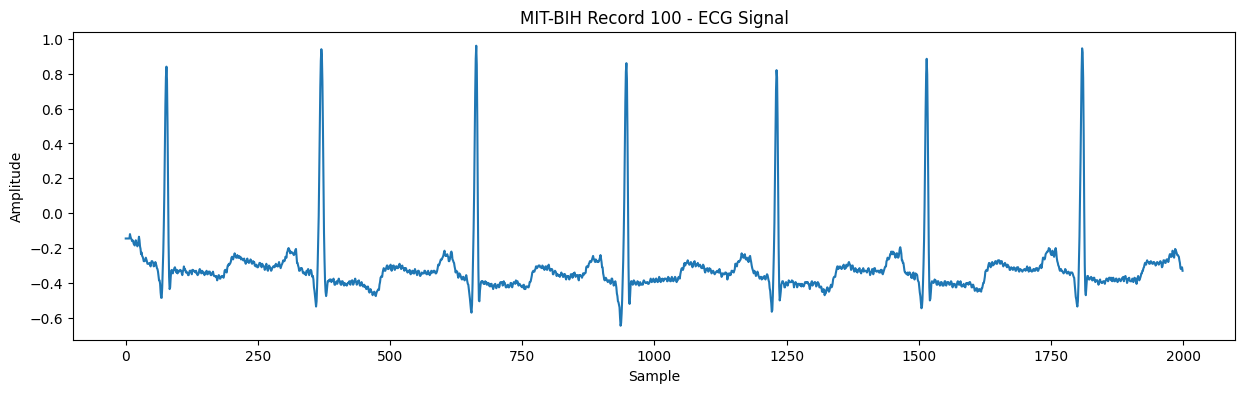

In [99]:
import wfdb
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/ECG/mitdb/mit-bih-arrhythmia-database-1.0.0"

# Read record 100
record = wfdb.rdrecord(f"{dataset_path}/100")

# Plot the first 2000 samples of the first ECG channel
plt.figure(figsize=(15, 4))
plt.plot(record.p_signal[:2000, 0])

plt.title("MIT-BIH Record 100 - ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

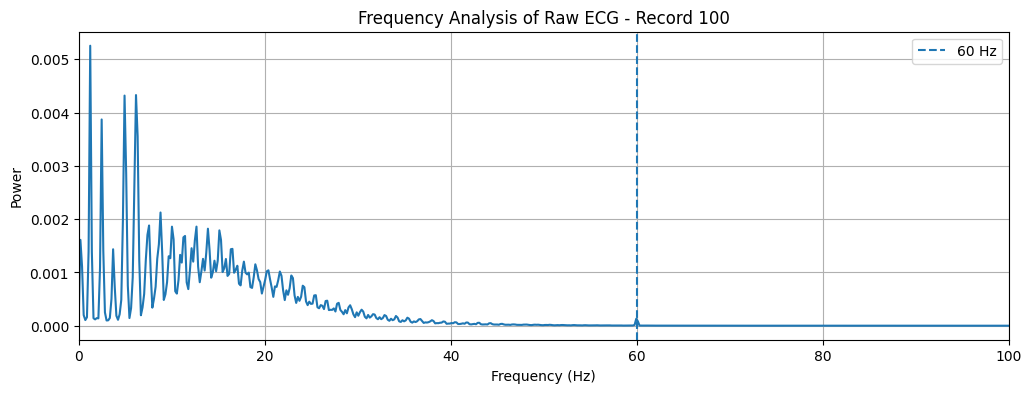

Signal sampling frequency: 360 Hz

Power analysis:
Low-frequency power (<0.5 Hz): 0.0029270883541549597
ECG-band power (0.5-40 Hz): 0.16249803634869062
High-frequency power (40-100 Hz): 0.0024431031963061275
Power around 60 Hz: 0.0002577574892034891


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Use the first ECG channel
signal = record.p_signal[:, 0]

# Use the first 20,000 samples only for analysis
# This is about 55.6 seconds at 360 Hz.
analysis_signal = signal[:20000]

# Remove the mean before frequency analysis
analysis_signal = analysis_signal - np.mean(analysis_signal)

# Calculate Power Spectral Density
frequencies, power = welch(
    analysis_signal,
    fs=record.fs,
    nperseg=2048
)

# --------------------------------------------------
# Plot frequency spectrum
# --------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(frequencies, power)

plt.xlim(0, 100)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Frequency Analysis of Raw ECG - Record 100")

plt.axvline(60, linestyle="--", label="60 Hz")

plt.legend()
plt.grid()
plt.show()

# --------------------------------------------------
# Check important frequency ranges
# --------------------------------------------------

low_frequency = power[(frequencies >= 0) & (frequencies < 0.5)]
ecg_band = power[(frequencies >= 0.5) & (frequencies <= 40)]
high_frequency = power[(frequencies > 40) & (frequencies <= 100)]

print("Signal sampling frequency:", record.fs, "Hz")

print("\nPower analysis:")
print("Low-frequency power (<0.5 Hz):",
      np.sum(low_frequency))

print("ECG-band power (0.5-40 Hz):",
      np.sum(ecg_band))

print("High-frequency power (40-100 Hz):",
      np.sum(high_frequency))

# Check power around 60 Hz
power_60hz = power[
    (frequencies >= 59) &
    (frequencies <= 61)
]

print("Power around 60 Hz:",
      np.sum(power_60hz))

In [101]:
# ============================================================
# AAMI EC57 CLASS MAPPING
# ============================================================
#
# Map original MIT-BIH annotation symbols into the
# five AAMI superclass labels.
#
# N = Normal
# S = Supraventricular ectopic
# V = Ventricular ectopic
# F = Fusion
# Q = Unknown / paced
#
# This cell ONLY defines the mapping.
# Beat extraction is performed later after ECG preprocessing.
# ============================================================

aami_mapping = {

    # --------------------------------------------------------
    # N — Normal
    # --------------------------------------------------------
    "N": "N",
    "L": "N",
    "R": "N",
    "e": "N",
    "j": "N",

    # --------------------------------------------------------
    # S — Supraventricular ectopic
    # --------------------------------------------------------
    "A": "S",
    "a": "S",
    "J": "S",
    "S": "S",

    # --------------------------------------------------------
    # V — Ventricular ectopic
    # --------------------------------------------------------
    "V": "V",
    "E": "V",

    # --------------------------------------------------------
    # F — Fusion
    # --------------------------------------------------------
    "F": "F",

    # --------------------------------------------------------
    # Q — Unknown / paced
    # --------------------------------------------------------
    "/": "Q",
    "f": "Q",
    "Q": "Q"
}


# ============================================================
# VERIFY MAPPING
# ============================================================

print("========== AAMI MAPPING ==========")

for symbol, class_name in aami_mapping.items():
    print(f"{symbol} -> {class_name}")


class_names = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]

print("\nAAMI classes:")
print(class_names)

========== AAMI MAPPING ==========
N -> N
L -> N
R -> N
e -> N
j -> N
A -> S
a -> S
J -> S
S -> S
V -> V
E -> V
F -> F
/ -> Q
f -> Q
Q -> Q

AAMI classes:
['N', 'S', 'V', 'F', 'Q']


In [102]:
DS1 = [
    "101", "106", "108", "109", "112", "114",
    "115", "116", "118", "119", "122", "124",
    "201", "203", "205", "207", "208", "209",
    "215", "220", "223", "230"
]

DS2 = [
    "100", "103", "105", "111", "113", "117",
    "121", "123", "200", "202", "210", "212",
    "213", "214", "219", "221", "222", "228",
    "231", "232", "233", "234"
]

excluded_records = [
    "102", "104", "107", "217"
]

print("DS1 training records:", len(DS1))
print("DS2 testing records:", len(DS2))
print("Excluded records:", excluded_records)

DS1 training records: 22
DS2 testing records: 22
Excluded records: ['102', '104', '107', '217']


In [103]:
import numpy as np
from scipy.signal import butter, filtfilt

In [104]:
# ============================================================
# ECG PREPROCESSING FUNCTION
# 0.5–40 Hz Butterworth Bandpass
# ============================================================



def preprocess_continuous_ecg(signal, fs=360):
    """
    Preprocess one continuous ECG signal.

    High-pass 0.5 Hz:
        Reduces slow baseline wandering.

    Low-pass 40 Hz:
        Reduces high-frequency noise.
    """

    signal = np.asarray(
        signal,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # High-pass filter: 0.5 Hz
    # --------------------------------------------------------

    b_high, a_high = butter(
        3,
        0.5 / (fs / 2),
        btype="high"
    )

    filtered = filtfilt(
        b_high,
        a_high,
        signal
    )

    # --------------------------------------------------------
    # Low-pass filter: 40 Hz
    # --------------------------------------------------------

    b_low, a_low = butter(
        3,
        40 / (fs / 2),
        btype="low"
    )

    filtered = filtfilt(
        b_low,
        a_low,
        filtered
    )

    return filtered


print("Preprocessing function defined successfully.")
print("High-pass: 0.5 Hz")
print("Low-pass : 40 Hz")
print("Filter   : 3rd-order Butterworth")

Preprocessing function defined successfully.
High-pass: 0.5 Hz
Low-pass : 40 Hz
Filter   : 3rd-order Butterworth


In [105]:
# Read Record 100
record_100 = wfdb.rdrecord(
    f"{dataset_path}/100"
)

raw_signal = record_100.p_signal[:, 0]
fs = record_100.fs

# Filter the continuous ECG
filtered_signal = preprocess_continuous_ecg(
    raw_signal,
    fs
)

print("Sampling frequency:", fs)
print("Raw signal length:", len(raw_signal))
print("Filtered signal length:", len(filtered_signal))

Sampling frequency: 360
Raw signal length: 650000
Filtered signal length: 650000


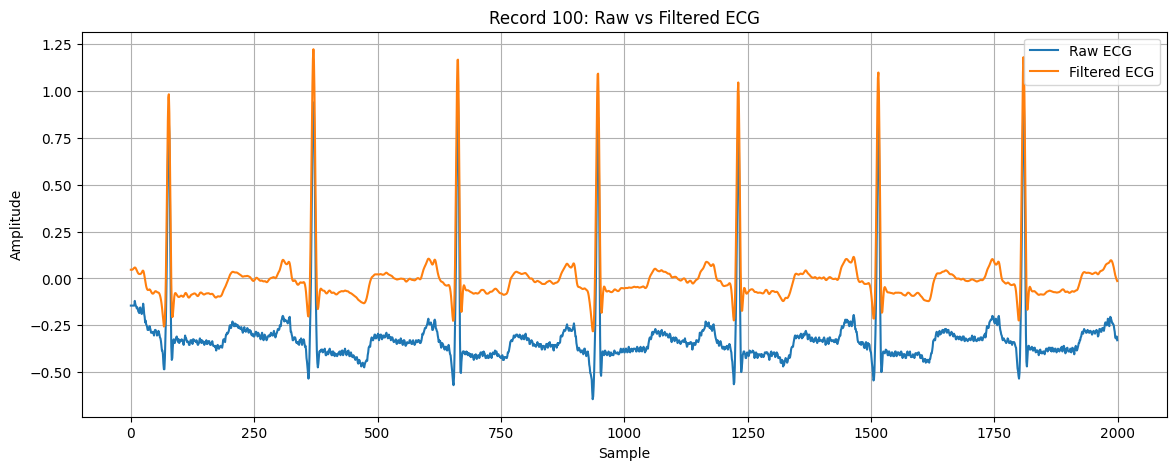

In [106]:
plt.figure(figsize=(14, 5))

plt.plot(
    raw_signal[:2000],
    label="Raw ECG"
)

plt.plot(
    filtered_signal[:2000],
    label="Filtered ECG"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Record 100: Raw vs Filtered ECG")

plt.legend()
plt.grid()

plt.show()

In [107]:
# ============================================================
# FINAL PREPROCESSING + BEAT EXTRACTION
# ============================================================

import os
import wfdb
import numpy as np

BEFORE = 90
AFTER = 180
WINDOW_SIZE = BEFORE + AFTER

X_processed = []
y_processed = []
record_ids_processed = []


# ============================================================
# PROCESS ONLY STANDARD DS1 + DS2 RECORDS
# ============================================================

for record_id in DS1 + DS2:

    record_path = os.path.join(
        dataset_path,
        record_id
    )

    # Read ECG record
    record = wfdb.rdrecord(record_path)

    # Read expert annotations
    annotation = wfdb.rdann(
        record_path,
        "atr"
    )

    # First ECG channel
    raw_signal = record.p_signal[:, 0]

    # Apply validated 0.5–40 Hz preprocessing
    clean_signal = preprocess_continuous_ecg(
        raw_signal,
        record.fs
    )

    # ========================================================
    # Extract beats around expert annotations
    # ========================================================

    for location, symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        # Keep only AAMI-mapped symbols
        if symbol not in aami_mapping:
            continue

        start = int(location) - BEFORE
        end = int(location) + AFTER

        # Skip incomplete windows
        if start < 0 or end > len(clean_signal):
            continue

        beat = clean_signal[start:end]

        if len(beat) != WINDOW_SIZE:
            continue

        X_processed.append(beat)
        y_processed.append(
            aami_mapping[symbol]
        )
        record_ids_processed.append(
            record_id
        )


# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

X_processed = np.asarray(
    X_processed,
    dtype=np.float32
)

y_processed = np.asarray(
    y_processed
)

record_ids_processed = np.asarray(
    record_ids_processed
)


# ============================================================
# PER-BEAT Z-SCORE NORMALIZATION
# ============================================================

mean = np.mean(
    X_processed,
    axis=1,
    keepdims=True
)

std = np.std(
    X_processed,
    axis=1,
    keepdims=True
)

# Prevent division by zero
std = np.where(
    std < 1e-8,
    1.0,
    std
)

X_processed = (
    X_processed - mean
) / std


# ============================================================
# FINAL PREPROCESSING CHECK
# ============================================================

print("========== PREPROCESSING RESULT ==========")

print(
    "X shape:",
    X_processed.shape
)

print(
    "y shape:",
    y_processed.shape
)

print(
    "Samples per beat:",
    X_processed.shape[1]
)

print(
    "Total beats:",
    X_processed.shape[0]
)

print(
    "Records used:",
    len(np.unique(record_ids_processed))
)

print(
    "Classes:",
    np.unique(y_processed)
)


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\n========== AAMI CLASS DISTRIBUTION ==========")

for label in ["N", "S", "V", "F", "Q"]:

    count = np.sum(
        y_processed == label
    )

    print(
        f"{label}: {count}"
    )


# ============================================================
# NORMALIZATION CHECK
# ============================================================

print("\n========== NORMALIZATION CHECK ==========")

print(
    "First beat mean:",
    np.mean(X_processed[0])
)

print(
    "First beat std:",
    np.std(X_processed[0])
)

========== PREPROCESSING RESULT ==========
X shape: (100694, 270)
y shape: (100694,)
Samples per beat: 270
Total beats: 100694
Records used: 44
Classes: ['F' 'N' 'Q' 'S' 'V']

========== AAMI CLASS DISTRIBUTION ==========
N: 90088
S: 2781
V: 7008
F: 802
Q: 15

========== NORMALIZATION CHECK ==========
First beat mean: -7.064254e-09
First beat std: 1.0


In [108]:
# ============================================================
# FINAL DS1 / DS2 SPLIT
# ============================================================

train_mask = np.isin(record_ids_processed, DS1)
test_mask = np.isin(record_ids_processed, DS2)

X_train = X_processed[train_mask]
y_train = y_processed[train_mask]

X_test = X_processed[test_mask]
y_test = y_processed[test_mask]

train_record_ids = record_ids_processed[train_mask]
test_record_ids = record_ids_processed[test_mask]

overlap = set(train_record_ids) & set(test_record_ids)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)
print("Record overlap:", overlap)

if overlap:
    raise RuntimeError(f"Record leakage detected: {overlap}")

print("DS1/DS2 split: PASS")

Training: (51002, 270)
Testing: (49692, 270)
Record overlap: set()
DS1/DS2 split: PASS


In [ ]:
# @title
# ============================================================
# FINAL CLASS PREPARATION + CLASS WEIGHTS
# Keep all 5 AAMI classes: N, S, V, F, Q
#
# Existing variables:
# X_processed
# y_processed
# record_ids_processed
#
# No filtering or signal preprocessing is repeated here.
# ============================================================

import numpy as np
import torch

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 2. Final DS1 / DS2 record definitions
# ------------------------------------------------------------

DS1 = [
    "101", "106", "108", "109", "112", "114",
    "115", "116", "118", "119", "122", "124",
    "201", "203", "205", "207", "208", "209",
    "215", "220", "223", "230"
]

DS2 = [
    "100", "103", "105", "111", "113", "117",
    "121", "123", "200", "202", "210", "212",
    "213", "214", "219", "221", "222", "228",
    "231", "232", "233", "234"
]


# ------------------------------------------------------------
# 3. Use the FINAL processed dataset
# ------------------------------------------------------------

X_final = np.asarray(
    X_processed,
    dtype=np.float32
)

y_final = np.asarray(
    y_processed
)

records_final = np.asarray(
    record_ids_processed
)


# ------------------------------------------------------------
# 4. Separate final processed beats into DS1 and DS2
# ------------------------------------------------------------

train_mask = np.isin(
    records_final,
    DS1
)

test_mask = np.isin(
    records_final,
    DS2
)

X_train = X_final[train_mask]
y_train_text = y_final[train_mask]

X_test = X_final[test_mask]
y_test_text = y_final[test_mask]


# ------------------------------------------------------------
# 5. Verify no record leakage
# ------------------------------------------------------------

train_records = set(
    records_final[train_mask]
)

test_records = set(
    records_final[test_mask]
)

overlap = train_records.intersection(
    test_records
)

print("========== RECORD LEAKAGE CHECK ==========")
print("Training records:", len(train_records))
print("Testing records :", len(test_records))
print("Overlap:", overlap)

if len(overlap) != 0:
    raise ValueError(
        f"Record leakage detected: {overlap}"
    )

print("No record overlap detected.")


# ------------------------------------------------------------
# 6. Keep all 5 AAMI classes
# ------------------------------------------------------------

label_map = {
    "N": 0,
    "S": 1,
    "V": 2,
    "F": 3,
    "Q": 4
}

class_names = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]


# ------------------------------------------------------------
# 7. Convert labels to integers
# ------------------------------------------------------------

y_train = np.array(
    [label_map[label] for label in y_train_text],
    dtype=np.int64
)

y_test = np.array(
    [label_map[label] for label in y_test_text],
    dtype=np.int64
)


# ------------------------------------------------------------
# 8. Final dataset shapes
# ------------------------------------------------------------

print("\n========== FINAL MODEL DATA ==========")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("Samples per beat:", X_train.shape[1])


# ------------------------------------------------------------
# 9. Final class distribution
# ------------------------------------------------------------

print("\n========== DS1 TRAINING DISTRIBUTION ==========")

class_counts = np.bincount(
    y_train,
    minlength=5
)

for class_id, label in enumerate(class_names):
    print(
        f"{label}: {class_counts[class_id]}"
    )


print("\n========== DS2 TESTING DISTRIBUTION ==========")

test_counts = np.bincount(
    y_test,
    minlength=5
)

for class_id, label in enumerate(class_names):
    print(
        f"{label}: {test_counts[class_id]}"
    )


# ------------------------------------------------------------
# 10. Calculate MODERATED class weights ONLY from DS1
# ------------------------------------------------------------
#
# Previous experiment:
#     weight = 1 / class_frequency
#
# This produced very large weights for rare classes,
# especially F and Q.
#
# New strategy:
#     weight = 1 / sqrt(class_frequency)
#
# This still gives higher importance to minority classes
# while reducing the extreme weighting effect.
#
# DS2 is NOT used to calculate these weights.
# ------------------------------------------------------------

num_classes = len(class_names)

raw_weights = 1.0 / np.sqrt(
    class_counts.astype(np.float64)
)

# Normalize weights so the average weight is 1
class_weights = (
    raw_weights / np.mean(raw_weights)
)


# ------------------------------------------------------------
# 11. Convert class weights to PyTorch tensor
# ------------------------------------------------------------

weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
)


# ------------------------------------------------------------
# 12. Display the new DS1 class weights
# ------------------------------------------------------------

print("\n========== MODERATED DS1 CLASS WEIGHTS ==========")

for label, weight in zip(
    class_names,
    class_weights
):
    print(
        f"{label}: {weight:.6f}"
    )


# ------------------------------------------------------------
# 13. Verify weighting behavior
# ------------------------------------------------------------

print(
    "\n========== MODERATED WEIGHTING CHECK =========="
)

for class_id, label in enumerate(class_names):

    weighted_contribution = (
        class_counts[class_id]
        * class_weights[class_id]
    )

    print(
        f"{label}: "
        f"count={class_counts[class_id]}, "
        f"weight={class_weights[class_id]:.6f}, "
        f"weighted contribution={weighted_contribution:.2f}"
    )


# ------------------------------------------------------------
# 14. Final confirmation
# ------------------------------------------------------------

print("\n========== READY FOR CNN ==========")

print(
    "Active classes:",
    class_names
)

print(
    "Imbalance strategy:",
    "Square-root inverse-frequency weighting"
)

print(
    "Weights calculated from DS1 only."
)

print(
    "DS2 remains completely untouched."
)

print(
    "Next step: retrain the CNN using these weights."
)

In [109]:
# ============================================================
# PART A — DS1 CLASS DISTRIBUTION
# ============================================================

from collections import Counter
import numpy as np

print("========== DS1 CLASS DISTRIBUTION ==========")

ds1_counts = Counter(y_train)

class_names = ["N", "S", "V", "F", "Q"]

for class_name in class_names:
    print(f"{class_name}: {ds1_counts.get(class_name, 0)}")

print("\nTotal DS1 beats:", len(y_train))
print("Unique DS1 records:", len(np.unique(train_record_ids)))

========== DS1 CLASS DISTRIBUTION ==========
N: 45848
S: 944
V: 3788
F: 414
Q: 8

Total DS1 beats: 51002
Unique DS1 records: 22


In [110]:
# ============================================================
# PART A — DS1 RECORD-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

import numpy as np

# ------------------------------------------------------------
# DS1 records
# ------------------------------------------------------------

DS1_records = np.array(DS1)

# ------------------------------------------------------------
# Fixed record-level split
# ------------------------------------------------------------
# 17 records for training
# 5 records for validation
#
# IMPORTANT:
# We split by RECORD, not individual ECG beats.
# This prevents beats from the same record appearing
# in both training and validation.
# ------------------------------------------------------------

train_records = np.array([
    "101", "106", "108", "109", "112",
    "114", "115", "116", "119", "122",
    "201", "203", "207", "208", "209",
    "220", "230"
])

val_records = np.array([
    "118", "124", "205", "215", "223"
])

# ------------------------------------------------------------
# Verify that all DS1 records are included exactly once
# ------------------------------------------------------------

assert set(train_records).union(set(val_records)) == set(DS1)

assert len(
    set(train_records).intersection(set(val_records))
) == 0

print("========== FINAL DS1 RECORD SPLIT ==========")

print("Training records:", len(train_records))
print("Validation records:", len(val_records))

print("Training records:")
print(train_records)

print("\nValidation records:")
print(val_records)

# ------------------------------------------------------------
# Create masks from processed data
# ------------------------------------------------------------

train_mask = np.isin(
    record_ids_processed,
    train_records
)

val_mask = np.isin(
    record_ids_processed,
    val_records
)

# ------------------------------------------------------------
# Create training and validation datasets
# ------------------------------------------------------------

X_DS1_train = X_processed[train_mask]
y_DS1_train = y_processed[train_mask]

X_DS1_val = X_processed[val_mask]
y_DS1_val = y_processed[val_mask]

train_record_ids = record_ids_processed[train_mask]
val_record_ids = record_ids_processed[val_mask]

# ------------------------------------------------------------
# Verify no record overlap
# ------------------------------------------------------------

record_overlap = set(train_record_ids).intersection(
    set(val_record_ids)
)

print("\nRecord overlap:", record_overlap)

if len(record_overlap) == 0:
    print("No DS1 train/validation record overlap detected.")
else:
    raise RuntimeError(
        f"Record leakage detected: {record_overlap}"
    )

# ------------------------------------------------------------
# Print dataset sizes
# ------------------------------------------------------------

print("\n========== DS1 TRAINING ==========")

print("Training beats:", len(X_DS1_train))
print("Training records:", len(np.unique(train_record_ids)))

print("\n========== DS1 VALIDATION ==========")

print("Validation beats:", len(X_DS1_val))
print("Validation records:", len(np.unique(val_record_ids)))

========== FINAL DS1 RECORD SPLIT ==========
Training records: 17
Validation records: 5
Training records:
['101' '106' '108' '109' '112' '114' '115' '116' '119' '122' '201' '203'
 '207' '208' '209' '220' '230']

Validation records:
['118' '124' '205' '215' '223']

Record overlap: set()
No DS1 train/validation record overlap detected.

========== DS1 TRAINING ==========
Training beats: 38486
Training records: 17

========== DS1 VALIDATION ==========
Validation beats: 12516
Validation records: 5


In [111]:
# ============================================================
# DS1 TRAINING / VALIDATION CLASS DISTRIBUTION
# ============================================================

from collections import Counter

print("========== DS1 TRAINING CLASS DISTRIBUTION ==========")

train_counts = Counter(y_DS1_train)

for class_name in ["N", "S", "V", "F", "Q"]:
    print(f"{class_name}: {train_counts.get(class_name, 0)}")

print("Total training beats:", len(y_DS1_train))


print("\n========== DS1 VALIDATION CLASS DISTRIBUTION ==========")

val_counts = Counter(y_DS1_val)

for class_name in ["N", "S", "V", "F", "Q"]:
    print(f"{class_name}: {val_counts.get(class_name, 0)}")

print("Total validation beats:", len(y_DS1_val))

========== DS1 TRAINING CLASS DISTRIBUTION ==========
N: 34340
S: 738
V: 3017
F: 383
Q: 8
Total training beats: 38486

========== DS1 VALIDATION CLASS DISTRIBUTION ==========
N: 11508
S: 206
V: 771
F: 31
Q: 0
Total validation beats: 12516


In [112]:
# ============================================================
# PART A — FINAL DS1 IMBALANCE HANDLING
# ============================================================
#
# Pipeline:
#
# DS1
#  |
#  +---- Training records
#  |       |
#  |       +--> Original training data
#  |       |
#  |       +--> Oversample S and F
#  |       |
#  |       +--> Calculate class weights
#  |
#  +---- Validation records
#          |
#          +--> NEVER oversampled
#          +--> NEVER used for class-weight calculation
#
# DS2
#  |
#  +--> Completely untouched
#
# Classes:
# N = Normal
# S = Supraventricular
# V = Ventricular
# F = Fusion
# Q = Unknown/Paced
# ============================================================


import numpy as np
import torch
from collections import Counter


# ============================================================
# 1. VERIFY ORIGINAL DS1 TRAINING DATA
# ============================================================

print("============================================================")
print("ORIGINAL DS1 TRAINING DATA")
print("============================================================")

train_counts = Counter(y_DS1_train)

class_names = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]

for class_name in class_names:

    print(
        f"{class_name}: "
        f"{train_counts.get(class_name, 0)}"
    )

print(
    "Total training beats:",
    len(y_DS1_train)
)


# ============================================================
# 2. VERIFY DS1 VALIDATION DATA
# ============================================================

print("\n============================================================")
print("DS1 VALIDATION DATA")
print("============================================================")

val_counts = Counter(y_DS1_val)

for class_name in class_names:

    print(
        f"{class_name}: "
        f"{val_counts.get(class_name, 0)}"
    )

print(
    "Total validation beats:",
    len(y_DS1_val)
)

print(
    "\nValidation is completely untouched."
)


# ============================================================
# 3. OVERSAMPLING — TRAINING DATA ONLY
# ============================================================
#
# We oversample:
#
# S -> approximately 4x total
# F -> approximately 4x total
#
# We DO NOT oversample:
#
# N
# V
# Q
#
# Validation is never modified.
# DS2 is never modified.
# ============================================================

rng = np.random.default_rng(42)


# ------------------------------------------------------------
# Original training data
# ------------------------------------------------------------

X_train_parts = [
    X_DS1_train
]

y_train_parts = [
    y_DS1_train
]


# ------------------------------------------------------------
# Oversample S
# ------------------------------------------------------------

S_indices = np.where(
    y_DS1_train == "S"
)[0]

if len(S_indices) > 0:

    S_extra_indices = rng.choice(
        S_indices,
        size=len(S_indices) * 3,
        replace=True
    )

    X_S_extra = X_DS1_train[
        S_extra_indices
    ]

    y_S_extra = y_DS1_train[
        S_extra_indices
    ]

    X_train_parts.append(
        X_S_extra
    )

    y_train_parts.append(
        y_S_extra
    )


# ------------------------------------------------------------
# Oversample F
# ------------------------------------------------------------

F_indices = np.where(
    y_DS1_train == "F"
)[0]

if len(F_indices) > 0:

    F_extra_indices = rng.choice(
        F_indices,
        size=len(F_indices) * 3,
        replace=True
    )

    X_F_extra = X_DS1_train[
        F_extra_indices
    ]

    y_F_extra = y_DS1_train[
        F_extra_indices
    ]

    X_train_parts.append(
        X_F_extra
    )

    y_train_parts.append(
        y_F_extra
    )


# ============================================================
# 4. CREATE FINAL BALANCED TRAINING DATA
# ============================================================

X_DS1_train_balanced = np.concatenate(
    X_train_parts,
    axis=0
)

y_DS1_train_balanced = np.concatenate(
    y_train_parts,
    axis=0
)


# ============================================================
# 5. VERIFY FINAL TRAINING DISTRIBUTION
# ============================================================

balanced_counts = Counter(
    y_DS1_train_balanced
)

print("\n============================================================")
print("FINAL TRAINING AFTER OVERSAMPLING")
print("============================================================")

for class_name in class_names:

    print(
        f"{class_name}: "
        f"{balanced_counts.get(class_name, 0)}"
    )

print(
    "\nTotal balanced training beats:",
    len(y_DS1_train_balanced)
)

print(
    "Oversampled classes: S, F"
)


# ============================================================
# 6. VALIDATION INTEGRITY CHECK
# ============================================================
#
# IMPORTANT:
# y_DS1_val must still contain exactly the original
# validation samples.
#
# We do NOT use X_DS1_train_balanced here.
# ============================================================

print("\n============================================================")
print("VALIDATION INTEGRITY CHECK")
print("============================================================")

print(
    "Validation beats:",
    len(y_DS1_val)
)

for class_name in class_names:

    print(
        f"{class_name}: "
        f"{val_counts.get(class_name, 0)}"
    )

print(
    "\nValidation remains completely untouched."
)


# ============================================================
# 7. CALCULATE CLASS WEIGHTS
# ============================================================
#
# IMPORTANT:
#
# Class weights are calculated from the ORIGINAL DS1
# training distribution.
#
# They are NOT calculated from the oversampled dataset.
#
# Square-root inverse-frequency weighting is used to
# moderate the effect of extreme class imbalance.
# ============================================================

original_counts = np.array(
    [
        train_counts.get(
            class_name,
            0
        )
        for class_name in class_names
    ],
    dtype=np.float64
)


# Prevent division by zero
safe_counts = np.maximum(
    original_counts,
    1.0
)


# Square-root inverse-frequency
raw_weights = 1.0 / np.sqrt(
    safe_counts
)


# Normalize average weight to 1
weights = (
    raw_weights /
    np.mean(raw_weights)
)


# Convert to PyTorch tensor
weights_tensor_final = torch.tensor(
    weights,
    dtype=torch.float32
)


# ============================================================
# 8. PRINT CLASS WEIGHTS
# ============================================================

print("\n============================================================")
print("FINAL CLASS WEIGHTS")
print("============================================================")

for class_name, weight in zip(
    class_names,
    weights
):

    print(
        f"{class_name}: {weight:.6f}"
    )


# ============================================================
# 9. FINAL SAFETY CHECKS
# ============================================================

assert len(
    X_DS1_train
) == len(
    y_DS1_train
)

assert len(
    X_DS1_train_balanced
) == len(
    y_DS1_train_balanced
)

assert len(
    X_DS1_val
) == len(
    y_DS1_val
)


# Make sure validation size did not change
assert len(
    y_DS1_val
) == sum(
    val_counts.values()
)


# Make sure the five expected classes exist in the
# weight vector
assert len(
    weights_tensor_final
) == 5


# ============================================================
# 10. FINAL PART A SUMMARY
# ============================================================

print("\n============================================================")
print("PART A — FINAL TRAINING DATA READY")
print("============================================================")

print(
    "Original training beats:",
    len(X_DS1_train)
)

print(
    "Balanced training beats:",
    len(X_DS1_train_balanced)
)

print(
    "Validation beats:",
    len(X_DS1_val)
)

print(
    "Oversampled classes: S, F"
)

print(
    "Validation modified: No"
)

print(
    "DS2 used: No"
)

print(
    "Class weighting: "
    "Square-root inverse-frequency"
)

print(
    "\nReady for CNN training."
)

ORIGINAL DS1 TRAINING DATA
N: 34340
S: 738
V: 3017
F: 383
Q: 8
Total training beats: 38486

DS1 VALIDATION DATA
N: 11508
S: 206
V: 771
F: 31
Q: 0
Total validation beats: 12516

Validation is completely untouched.

FINAL TRAINING AFTER OVERSAMPLING
N: 34340
S: 2952
V: 3017
F: 1532
Q: 8

Total balanced training beats: 41849
Oversampled classes: S, F

VALIDATION INTEGRITY CHECK
Validation beats: 12516
N: 11508
S: 206
V: 771
F: 31
Q: 0

Validation remains completely untouched.

FINAL CLASS WEIGHTS
N: 0.058017
S: 0.395758
V: 0.195736
F: 0.549361
Q: 3.801128

PART A — FINAL TRAINING DATA READY
Original training beats: 38486
Balanced training beats: 41849
Validation beats: 12516
Oversampled classes: S, F
Validation modified: No
DS2 used: No
Class weighting: Square-root inverse-frequency

Ready for CNN training.


In [113]:
# ============================================================
# PART A — CNN TRAINING
# 5-CLASS ECG BEAT CLASSIFICATION
# 1D CNN + WEIGHTED CROSS-ENTROPY LOSS
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)


# ============================================================
# 1. REPRODUCIBILITY + DEVICE
# ============================================================

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# 2. CLASS MAPPING
# ============================================================

class_names = ["N", "S", "V", "F", "Q"]

label_map = {
    "N": 0,
    "S": 1,
    "V": 2,
    "F": 3,
    "Q": 4
}

print("\n========== CLASS MAPPING ==========")

for label, class_id in label_map.items():
    print(f"{label} -> {class_id}")


# ============================================================
# 3. VERIFY FINAL PART A DATA
# ============================================================

print("\n========== FINAL PART A DATA CHECK ==========")

print(
    "Original training:",
    X_DS1_train.shape
)

print(
    "Balanced training:",
    X_DS1_train_balanced.shape
)

print(
    "Validation:",
    X_DS1_val.shape
)

print(
    "Original training labels:",
    y_DS1_train.shape
)

print(
    "Balanced training labels:",
    y_DS1_train_balanced.shape
)

print(
    "Validation labels:",
    y_DS1_val.shape
)


# ============================================================
# 4. CONVERT STRING LABELS TO INTEGER LABELS
# ============================================================

y_train_encoded = np.array([
    label_map[label]
    for label in y_DS1_train_balanced
])

y_val_encoded = np.array([
    label_map[label]
    for label in y_DS1_val
])


print("\n========== LABEL ENCODING CHECK ==========")

print(
    "Training classes:",
    np.unique(y_train_encoded)
)

print(
    "Validation classes:",
    np.unique(y_val_encoded)
)


# ============================================================
# 5. CREATE PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(
    X_DS1_train_balanced,
    dtype=torch.float32
).unsqueeze(1)

y_train_tensor = torch.tensor(
    y_train_encoded,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_DS1_val,
    dtype=torch.float32
).unsqueeze(1)

y_val_tensor = torch.tensor(
    y_val_encoded,
    dtype=torch.long
)


print("\n========== PYTORCH INPUT SHAPES ==========")

print(
    "Training X:",
    X_train_tensor.shape
)

print(
    "Training y:",
    y_train_tensor.shape
)

print(
    "Validation X:",
    X_val_tensor.shape
)

print(
    "Validation y:",
    y_val_tensor.shape
)


# ============================================================
# 6. DATASETS
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)


# ============================================================
# 7. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)


print("\n========== DATALOADERS ==========")

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)


# ============================================================
# 8. CLASS WEIGHTS
# ============================================================

weights_tensor_final = weights_tensor_final.to(device)

print("\n========== CLASS WEIGHTS ==========")

for class_id, label in enumerate(class_names):

    print(
        f"{label}: "
        f"{weights_tensor_final[class_id].item():.6f}"
    )


# ============================================================
# 9. 1D CNN MODEL
# ============================================================

class ECG1DCNN(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        self.features = nn.Sequential(

            # -------------------------
            # Convolution Block 1
            # -------------------------

            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Dropout(0.10),


            # -------------------------
            # Convolution Block 2
            # -------------------------

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Dropout(0.15),


            # -------------------------
            # Convolution Block 3
            # -------------------------

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Dropout(0.20),


            # -------------------------
            # Convolution Block 4
            # -------------------------

            nn.Conv1d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.20)
        )


        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)


        # Fully connected classifier
        self.classifier = nn.Sequential(

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(
                64,
                num_classes
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = x.squeeze(-1)

        x = self.classifier(x)

        return x


model = ECG1DCNN(
    num_classes=5
).to(device)


print("\n========== CNN MODEL ==========")

print(model)


# ============================================================
# 10. WEIGHTED CROSS-ENTROPY LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=weights_tensor_final
)


print("\n========== LOSS FUNCTION ==========")

print("Weighted Cross-Entropy Loss")
print("Class weights: ENABLED")
print("Focal Loss: NOT USED")


# ============================================================
# 11. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# ============================================================
# 12. TRAINING CONFIGURATION
# ============================================================

NUM_EPOCHS = 15

best_macro_f1 = -1.0

best_model_state = None


print("\n========== STARTING CNN TRAINING ==========")


# ============================================================
# 13. TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    total_train_loss = 0.0
    total_train_samples = 0


    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)


        optimizer.zero_grad()


        outputs = model(batch_x)


        loss = criterion(
            outputs,
            batch_y
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )


        optimizer.step()


        batch_size = batch_x.size(0)

        total_train_loss += (
            loss.item() * batch_size
        )

        total_train_samples += batch_size


    train_loss = (
        total_train_loss
        / total_train_samples
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    total_val_loss = 0.0
    total_val_samples = 0

    predictions = []
    actual_labels = []


    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)


            outputs = model(batch_x)


            loss = criterion(
                outputs,
                batch_y
            )


            batch_size = batch_x.size(0)

            total_val_loss += (
                loss.item() * batch_size
            )

            total_val_samples += batch_size


            pred = torch.argmax(
                outputs,
                dim=1
            )


            predictions.extend(
                pred.cpu().numpy()
            )

            actual_labels.extend(
                batch_y.cpu().numpy()
            )


    val_loss = (
        total_val_loss
        / total_val_samples
    )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_accuracy = accuracy_score(
        actual_labels,
        predictions
    )


    # Q is absent from DS1 validation,
    # therefore model selection uses N/S/V/F.

    macro_f1 = f1_score(
        actual_labels,
        predictions,
        labels=[0, 1, 2, 3],
        average="macro",
        zero_division=0
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if macro_f1 > best_macro_f1:

        best_macro_f1 = macro_f1

        best_model_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }


    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy * 100:.2f}% | "
        f"Val Macro F1 (N/S/V/F): {macro_f1:.4f}",
        flush=True
    )


# ============================================================
# 14. RESTORE BEST MODEL
# ============================================================

if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

    model.to(device)


print("\n========== TRAINING COMPLETE ==========")

print(
    f"Best Validation Macro F1 "
    f"(N/S/V/F): {best_macro_f1:.4f}"
)


# ============================================================
# 15. FINAL VALIDATION PREDICTIONS
# ============================================================

model.eval()

final_predictions = []
final_labels = []


with torch.no_grad():

    for batch_x, batch_y in val_loader:

        batch_x = batch_x.to(device)

        outputs = model(batch_x)


        pred = torch.argmax(
            outputs,
            dim=1
        )


        final_predictions.extend(
            pred.cpu().numpy()
        )

        final_labels.extend(
            batch_y.numpy()
        )


# ============================================================
# 16. FINAL VALIDATION REPORT
# ============================================================

print(
    "\n========== FINAL DS1 VALIDATION REPORT =========="
)

print(
    classification_report(
        final_labels,
        final_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_names,
        zero_division=0
    )
)


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    final_labels,
    final_predictions,
    labels=[0, 1, 2, 3, 4]
)

print(
    "\n========== DS1 VALIDATION CONFUSION MATRIX =========="
)

print(cm)

Using device: cpu

========== CLASS MAPPING ==========
N -> 0
S -> 1
V -> 2
F -> 3
Q -> 4

========== FINAL PART A DATA CHECK ==========
Original training: (38486, 270)
Balanced training: (41849, 270)
Validation: (12516, 270)
Original training labels: (38486,)
Balanced training labels: (41849,)
Validation labels: (12516,)

========== LABEL ENCODING CHECK ==========
Training classes: [0 1 2 3 4]
Validation classes: [0 1 2 3]

========== PYTORCH INPUT SHAPES ==========
Training X: torch.Size([41849, 1, 270])
Training y: torch.Size([41849])
Validation X: torch.Size([12516, 1, 270])
Validation y: torch.Size([12516])

========== DATALOADERS ==========
Training batches: 327
Validation batches: 49

========== CLASS WEIGHTS ==========
N: 0.058017
S: 0.395758
V: 0.195736
F: 0.549361
Q: 3.801128

========== CNN MODEL ==========
ECG1DCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, tra

In [114]:
# ============================================================
# PART A — FINAL DS2 TEST LOADER
# ============================================================

import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# AAMI class mapping — keep this consistent everywhere
label_map = {
    "N": 0,
    "S": 1,
    "V": 2,
    "F": 3,
    "Q": 4
}

# ------------------------------------------------------------
# Encode DS2 labels if they are still strings
# ------------------------------------------------------------

if isinstance(y_test, np.ndarray) and np.issubdtype(y_test.dtype, np.str_):
    unknown_labels = set(np.unique(y_test)) - set(label_map.keys())

    if unknown_labels:
        raise ValueError(
            f"Unknown labels found in y_test: {unknown_labels}"
        )

    y_test = np.array(
        [label_map[label] for label in y_test],
        dtype=np.int64
    )

else:
    y_test = np.asarray(
        y_test,
        dtype=np.int64
    )

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if not np.all(
    np.isin(
        y_test,
        [0, 1, 2, 3, 4]
    )
):
    raise ValueError(
        "y_test contains labels outside the AAMI classes 0-4."
    )

# ------------------------------------------------------------
# Create tensors
# ------------------------------------------------------------

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

# ------------------------------------------------------------
# Create DataLoader
# ------------------------------------------------------------

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("DS2 test loader created.")
print("DS2 beats:", len(test_dataset))
print("Test batches:", len(test_loader))
print("Input shape:", X_test_tensor.shape)
print("Labels:", torch.unique(y_test_tensor).tolist())

# Show class distribution
for class_name, class_id in label_map.items():
    count = int(np.sum(y_test == class_id))
    print(f"{class_name}: {count}")

DS2 test loader created.
DS2 beats: 49692
Test batches: 195
Input shape: torch.Size([49692, 1, 270])
Labels: [0, 1, 2, 3, 4]
N: 44240
S: 1837
V: 3220
F: 388
Q: 7


In [115]:
# ============================================================
# PART B — FINAL DS2 EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

model.eval()

test_predictions = []
test_actual = []

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)

        outputs = model(batch_x)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_actual.extend(
            batch_y.numpy()
        )


# ============================================================
# DS2 ACCURACY
# ============================================================

test_accuracy = accuracy_score(
    test_actual,
    test_predictions
)

print("=" * 60)
print("FINAL DS2 TEST RESULTS")
print("=" * 60)

print(
    f"DS2 Accuracy: {test_accuracy * 100:.2f}%"
)


# ============================================================
# DS2 MACRO F1 — N/S/V/F
# ============================================================

test_macro_f1 = f1_score(
    test_actual,
    test_predictions,
    labels=[0, 1, 2, 3],
    average="macro",
    zero_division=0
)

print(
    f"DS2 Macro F1 (N/S/V/F): {test_macro_f1:.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("DS2 CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        test_actual,
        test_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_names,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

test_cm = confusion_matrix(
    test_actual,
    test_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("\n" + "=" * 60)
print("DS2 CONFUSION MATRIX")
print("=" * 60)

print(test_cm)


# ============================================================
# PREDICTED CLASS DISTRIBUTION
# ============================================================

predicted_counts = Counter(
    test_predictions
)

print("\n" + "=" * 60)
print("DS2 PREDICTED CLASS COUNTS")
print("=" * 60)

for class_id, class_name in enumerate(class_names):

    print(
        f"{class_name}: "
        f"{predicted_counts.get(class_id, 0)}"
    )

FINAL DS2 TEST RESULTS
DS2 Accuracy: 81.08%
DS2 Macro F1 (N/S/V/F): 0.3789

DS2 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           N       0.94      0.85      0.89     44240
           S       0.04      0.06      0.04      1837
           V       0.45      0.81      0.58      3220
           F       0.00      0.00      0.00       388
           Q       0.00      0.00      0.00         7

    accuracy                           0.81     49692
   macro avg       0.29      0.34      0.30     49692
weighted avg       0.87      0.81      0.83     49692


DS2 CONFUSION MATRIX
[[37572  2650  2988  1030     0]
 [ 1539   106   181    11     0]
 [  527    43  2612    38     0]
 [  174   170    44     0     0]
 [    2     1     3     1     0]]

DS2 PREDICTED CLASS COUNTS
N: 39814
S: 2970
V: 5828
F: 1080
Q: 0


part B


In [118]:
# ============================================================
# PART B — B0
# SAVE FINAL PART A BASELINE MODEL
# ============================================================

import torch
import os

MODEL_VERSION = "cnn_v1.0"
MODEL_PATH = "/content/drive/MyDrive/ECG/cnn_v1.0_baseline.pt"

# Make absolutely sure we are using the BEST Part A model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

model.eval()

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_version": MODEL_VERSION,
    "class_names": class_names,
    "num_classes": len(class_names),
}

torch.save(checkpoint, MODEL_PATH)

print("============================================================")
print("PART A BASELINE MODEL SAVED")
print("============================================================")
print("Model version:", MODEL_VERSION)
print("Saved path:", MODEL_PATH)
print("Classes:", class_names)
print("Number of classes:", len(class_names))
print("Device:", device)
print("Model set to evaluation mode:", not model.training)
print("File exists:", os.path.exists(MODEL_PATH))
print("============================================================")

PART A BASELINE MODEL SAVED
Model version: cnn_v1.0
Saved path: /content/drive/MyDrive/ECG/cnn_v1.0_baseline.pt
Classes: ['N', 'S', 'V', 'F', 'Q']
Number of classes: 5
Device: cpu
Model set to evaluation mode: True
File exists: True


In [120]:
# ============================================================
# PART B — B1
# SQLITE DATABASE INITIALIZATION
# ============================================================

import sqlite3
import os

# ------------------------------------------------------------
# Database configuration
# ------------------------------------------------------------

DB_PATH = "/content/drive/MyDrive/ECG/ecg_pipeline.db"

# ------------------------------------------------------------
# Connect to SQLite
# ------------------------------------------------------------

conn = sqlite3.connect(DB_PATH)

cursor = conn.cursor()

# ------------------------------------------------------------
# Create classified_beats table
# ------------------------------------------------------------

cursor.execute("""
CREATE TABLE IF NOT EXISTS classified_beats (

    unique_beat_id TEXT PRIMARY KEY,

    source_record TEXT NOT NULL,

    timestamp DATETIME NOT NULL,

    input_signal_ref TEXT,

    predicted_label TEXT NOT NULL,

    confidence REAL NOT NULL,

    model_version TEXT NOT NULL
)
""")

# ------------------------------------------------------------
# Create useful indexes
# ------------------------------------------------------------

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_classified_beats_record
ON classified_beats(source_record)
""")

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_classified_beats_prediction
ON classified_beats(predicted_label)
""")

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_classified_beats_model
ON classified_beats(model_version)
""")

conn.commit()

# ------------------------------------------------------------
# Verify schema
# ------------------------------------------------------------

cursor.execute("""
PRAGMA table_info(classified_beats)
""")

schema = cursor.fetchall()

print("============================================================")
print("PART B — SQLITE INITIALIZATION")
print("============================================================")

print("Database path:", DB_PATH)
print("Database exists:", os.path.exists(DB_PATH))

print("\nTable: classified_beats")
print("--------------------------------------------")

for column in schema:
    print(
        f"Column: {column[1]:20s} "
        f"Type: {column[2]:10s} "
        f"Primary Key: {column[5]}"
    )

# ------------------------------------------------------------
# Verify table is currently empty
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM classified_beats
""")

row_count = cursor.fetchone()[0]

print("\nCurrent classified beats:", row_count)

print("\nSQLite initialization successful.")
conn.close()
print("SQLite connection closed.")

# Keep connection available for the next Part B cells.

PART B — SQLITE INITIALIZATION
Database path: /content/drive/MyDrive/ECG/ecg_pipeline.db
Database exists: True

Table: classified_beats
--------------------------------------------
Column: unique_beat_id       Type: TEXT       Primary Key: 1
Column: source_record        Type: TEXT       Primary Key: 0
Column: timestamp            Type: DATETIME   Primary Key: 0
Column: input_signal_ref     Type: TEXT       Primary Key: 0
Column: predicted_label      Type: TEXT       Primary Key: 0
Column: confidence           Type: REAL       Primary Key: 0
Column: model_version        Type: TEXT       Primary Key: 0

Current classified beats: 49693

SQLite initialization successful.
SQLite connection closed.


In [75]:
from google.colab import drive
import os

drive.mount("/content/drive")

MODEL_PATH = "/content/drive/MyDrive/ECG/cnn_v1.0_baseline.pt"

print("Model exists:", os.path.exists(MODEL_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model exists: True


In [121]:
# ============================================================
# PART B — B3
# LOAD BASELINE + DS2 INFERENCE + SQLITE PERSISTENCE
# WITH ACTUAL SOURCE-RECORD MAPPING
# ============================================================

import os
import time
import sqlite3
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn


# ============================================================
# CONFIGURATION
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/ECG/"
    "cnn_v1.0_baseline.pt"
)

DB_PATH = (
    "/content/drive/MyDrive/ECG/"
    "ecg_pipeline.db"
)

MODEL_VERSION = "cnn_v1.0"

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# RECREATE EXACT PART A CNN ARCHITECTURE
# ============================================================

class ECG1DCNN(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1, 32,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),

            nn.Conv1d(
                32, 64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.15),

            nn.Conv1d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.20),

            nn.Conv1d(
                128, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)

        return self.classifier(x)


# ============================================================
# VERIFY REQUIRED INPUTS
# ============================================================

if "test_loader" not in globals():
    raise RuntimeError(
        "test_loader is not available. "
        "Run the final Part A DS2 preparation first."
    )

if "class_names" not in globals():
    raise RuntimeError(
        "class_names is not available."
    )


# ============================================================
# FIND ACTUAL DS2 SOURCE-RECORD IDS
# ============================================================
#
# We do NOT invent the record IDs.
# One of these variables must have been created in Part A
# with exactly one source record ID per DS2 beat.
# ============================================================

record_id_candidates = [
    "test_record_ids",
    "ds2_record_ids",
    "X_test_record_ids",
    "test_source_records",
    "ds2_source_records"
]

source_record_ids = None
source_variable_name = None

for variable_name in record_id_candidates:

    if variable_name in globals():

        candidate = np.asarray(
            globals()[variable_name]
        )

        if candidate.ndim == 1:
            source_record_ids = candidate
            source_variable_name = variable_name
            break

if source_record_ids is None:

    raise RuntimeError(
        "Actual DS2 source-record IDs were not found.\n"
        "Create one record ID per DS2 beat in Part A "
        "and expose it using one of these variable names:\n"
        + ", ".join(record_id_candidates)
    )


# ============================================================
# VERIFY SOURCE-RECORD ALIGNMENT
# ============================================================

EXPECTED_DS2_SIZE = 49692

if len(source_record_ids) != EXPECTED_DS2_SIZE:

    raise RuntimeError(
        "Source-record ID count does not match DS2.\n"
        f"Expected: {EXPECTED_DS2_SIZE}\n"
        f"Found: {len(source_record_ids)}"
    )

print("=" * 70)
print("PART B — B3")
print("BASELINE INFERENCE + ACTUAL SOURCE-RECORD PERSISTENCE")
print("=" * 70)

print(
    "Source-record variable:",
    source_variable_name
)

print(
    "DS2 beats:",
    len(source_record_ids)
)


# ============================================================
# LOAD SAVED PART A BASELINE
# ============================================================

model = ECG1DCNN(
    num_classes=5
).to(device)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if "model_state_dict" not in checkpoint:

    raise RuntimeError(
        "Baseline checkpoint does not contain "
        "'model_state_dict'."
    )

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# ============================================================
# RUN INFERENCE
# ============================================================

records = []

beat_index = 0
total_latency = 0.0

with torch.no_grad():

    for batch_x, _ in test_loader:

        batch_x = batch_x.to(device)

        start = time.perf_counter()

        logits = model(batch_x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

        total_latency += (
            time.perf_counter() - start
        )

        predictions = (
            predictions
            .cpu()
            .numpy()
        )

        confidence = (
            confidence
            .cpu()
            .numpy()
        )

        for pred, conf in zip(
            predictions,
            confidence
        ):

            # ------------------------------------------------
            # Actual MIT-BIH source record for this beat
            # ------------------------------------------------

            source_record = str(
                source_record_ids[beat_index]
            )

            unique_beat_id = (
                f"DS2_{beat_index:05d}"
            )

            input_signal_ref = (
                f"{source_record}_"
                f"DS2_beat_{beat_index:05d}"
            )

            timestamp = (
                datetime.now().isoformat()
            )

            records.append(
                (
                    unique_beat_id,
                    source_record,
                    timestamp,
                    input_signal_ref,
                    class_names[int(pred)],
                    float(conf),
                    MODEL_VERSION
                )
            )

            beat_index += 1


# ============================================================
# VERIFY ALL DS2 BEATS WERE PROCESSED
# ============================================================

if beat_index != EXPECTED_DS2_SIZE:

    raise RuntimeError(
        f"Processed {beat_index} beats, "
        f"expected {EXPECTED_DS2_SIZE}."
    )

if len(records) != EXPECTED_DS2_SIZE:

    raise RuntimeError(
        f"Created {len(records)} persistence records, "
        f"expected {EXPECTED_DS2_SIZE}."
    )


# ============================================================
# PERSIST TO SQLITE
# ============================================================

conn = sqlite3.connect(
    DB_PATH,
    timeout=30
)

try:

    conn.executemany(
        """
        INSERT OR REPLACE INTO classified_beats
        (
            unique_beat_id,
            source_record,
            timestamp,
            input_signal_ref,
            predicted_label,
            confidence,
            model_version
        )
        VALUES (?, ?, ?, ?, ?, ?, ?)
        """,
        records
    )

    conn.commit()

    count = conn.execute(
        """
        SELECT COUNT(*)
        FROM classified_beats
        """
    ).fetchone()[0]

finally:

    conn.close()


# ============================================================
# VERIFY SOURCE-RECORD PERSISTENCE
# ============================================================

conn = sqlite3.connect(
    DB_PATH,
    timeout=30
)

try:

    persisted_source_records = conn.execute(
        """
        SELECT COUNT(DISTINCT source_record)
        FROM classified_beats
        """
    ).fetchone()[0]

    sample_rows = conn.execute(
        """
        SELECT
            unique_beat_id,
            source_record,
            predicted_label,
            confidence,
            model_version,
            timestamp
        FROM classified_beats
        ORDER BY unique_beat_id
        LIMIT 5
        """
    ).fetchall()

finally:

    conn.close()


# ============================================================
# RESULT
# ============================================================

print(
    "\nPART B — INFERENCE COMPLETE"
)

print(
    "Beats processed:",
    beat_index
)

print(
    "Records persisted:",
    count
)

print(
    "Distinct source records persisted:",
    persisted_source_records
)

print(
    f"Total inference latency: "
    f"{total_latency:.4f} sec"
)

print(
    "\nSample persisted records:"
)

for row in sample_rows:
    print(row)

print(
    "\n✅ Actual source-record IDs were persisted."
)

print(
    "✅ Each beat retains its source record."
)

print(
    "✅ Prediction, confidence, model version, "
    "and timestamp were persisted."
)

PART B — B3
BASELINE INFERENCE + ACTUAL SOURCE-RECORD PERSISTENCE
Source-record variable: test_record_ids
DS2 beats: 49692

PART B — INFERENCE COMPLETE
Beats processed: 49692
Records persisted: 49693
Distinct source records persisted: 23
Total inference latency: 16.2441 sec

Sample persisted records:
('C8_20260819051254953108', 'EXTERNAL', 'N', 0.9943325519561768, 'cnn_v2.0', '2026-08-19T05:12:54.953197+00:00')
('DS2_00000', '100', 'N', 0.990607738494873, 'cnn_v1.0', '2026-08-19T06:12:09.574131')
('DS2_00001', '100', 'N', 0.8009613752365112, 'cnn_v1.0', '2026-08-19T06:12:09.574188')
('DS2_00002', '100', 'N', 0.8945605158805847, 'cnn_v1.0', '2026-08-19T06:12:09.574196')
('DS2_00003', '100', 'N', 0.8701374530792236, 'cnn_v1.0', '2026-08-19T06:12:09.574201')

✅ Actual source-record IDs were persisted.
✅ Each beat retains its source record.
✅ Prediction, confidence, model version, and timestamp were persisted.


In [122]:
import sqlite3

DB_PATH = "/content/drive/MyDrive/ECG/ecg_pipeline.db"

conn = sqlite3.connect(DB_PATH)

count = conn.execute(
    "SELECT COUNT(*) FROM classified_beats"
).fetchone()[0]

print("Total classified beats:", count)

conn.close()

Total classified beats: 49693


In [123]:
def predict_beat(beat_tensor):
    """
    Classify one preprocessed ECG beat.

    Input:
        beat_tensor: ECG beat with shape [270]

    Returns:
        predicted class and confidence
    """

    model.eval()

    x = torch.tensor(
        beat_tensor,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probabilities = torch.softmax(logits, dim=1)

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_label = class_names[
        prediction.item()
    ]

    return predicted_label, float(confidence.item())

In [124]:
label, confidence = predict_beat(X_test[0])

print("Predicted class:", label)
print("Confidence:", confidence)

Predicted class: N
Confidence: 0.990607738494873


In [125]:
# ============================================================
# PART C — C0
# INSPECT PART B CLASSIFIED BEATS
# ============================================================

import sqlite3
from collections import Counter

DB_PATH = "/content/drive/MyDrive/ECG/ecg_pipeline.db"

conn = sqlite3.connect(DB_PATH)

# Total records
total = conn.execute("""
    SELECT COUNT(*)
    FROM classified_beats
""").fetchone()[0]

print("=" * 60)
print("PART C — EXISTING CLASSIFIED BEATS")
print("=" * 60)

print("Total classified beats:", total)

# Model versions
print("\nModel versions:")

for row in conn.execute("""
    SELECT model_version, COUNT(*)
    FROM classified_beats
    GROUP BY model_version
"""):
    print(row)

# Predicted labels
print("\nPredicted class distribution:")

for row in conn.execute("""
    SELECT predicted_label, COUNT(*)
    FROM classified_beats
    GROUP BY predicted_label
    ORDER BY predicted_label
"""):
    print(row)

# Source records
print("\nSource records:", end=" ")

source_count = conn.execute("""
    SELECT COUNT(DISTINCT source_record)
    FROM classified_beats
""").fetchone()[0]

print(source_count)

conn.close()

print("\nC0 inspection complete.")

PART C — EXISTING CLASSIFIED BEATS
Total classified beats: 49693

Model versions:
('cnn_v1.0', 49692)
('cnn_v2.0', 1)

Predicted class distribution:
('F', 1080)
('N', 39815)
('S', 2970)
('V', 5828)

Source records: 23

C0 inspection complete.


In [126]:
# ============================================================
# PART C — C1
# IMMUTABLE / APPEND-ONLY RECLASSIFICATION AUDIT TRAIL
# ============================================================

import sqlite3
from datetime import datetime

DB_PATH = "/content/drive/MyDrive/ECG/ecg_pipeline.db"

VALID_CLASSES = ("N", "S", "V", "F", "Q")

print("=" * 70)
print("PART C — C1")
print("IMMUTABLE APPEND-ONLY RECLASSIFICATION AUDIT TRAIL")
print("=" * 70)

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# ============================================================
# 1. CREATE AUDIT TABLE IF IT DOES NOT ALREADY EXIST
# ============================================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS reclassification_audit (

    audit_id INTEGER PRIMARY KEY AUTOINCREMENT,

    unique_beat_id TEXT NOT NULL,

    old_label TEXT NOT NULL,

    new_label TEXT NOT NULL,

    reviewer TEXT NOT NULL,

    correction_timestamp TEXT NOT NULL,

    original_model_version TEXT NOT NULL,

    CHECK (old_label IN ('N', 'S', 'V', 'F', 'Q')),

    CHECK (new_label IN ('N', 'S', 'V', 'F', 'Q'))

)
""")

# ============================================================
# 2. VERIFY REQUIRED COLUMNS
# ============================================================

columns = cursor.execute("""
PRAGMA table_info(reclassification_audit)
""").fetchall()

existing_columns = {
    row[1]
    for row in columns
}

required_columns = {
    "audit_id",
    "unique_beat_id",
    "old_label",
    "new_label",
    "reviewer",
    "correction_timestamp",
    "original_model_version"
}

missing_columns = required_columns - existing_columns

if missing_columns:

    conn.close()

    raise RuntimeError(
        "reclassification_audit is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

print("\n✅ Audit table verified.")

print("Columns:")
for column in sorted(existing_columns):
    print("  -", column)


# ============================================================
# 3. PREVENT UPDATE OF HISTORICAL AUDIT RECORDS
# ============================================================
#
# Once a clinician correction is inserted, it becomes
# immutable.
#
# No notebook cell or application code can silently modify
# the historical record.
#
# ============================================================

cursor.execute("""
CREATE TRIGGER IF NOT EXISTS prevent_audit_update
BEFORE UPDATE ON reclassification_audit
BEGIN

    SELECT RAISE(
        ABORT,
        'IMMUTABLE AUDIT TRAIL: UPDATE is not allowed.'
    );

END;
""")


# ============================================================
# 4. PREVENT DELETE OF HISTORICAL AUDIT RECORDS
# ============================================================

cursor.execute("""
CREATE TRIGGER IF NOT EXISTS prevent_audit_delete
BEFORE DELETE ON reclassification_audit
BEGIN

    SELECT RAISE(
        ABORT,
        'IMMUTABLE AUDIT TRAIL: DELETE is not allowed.'
    );

END;
""")


# ============================================================
# 5. CREATE INDEX FOR AUDIT LOOKUPS
# ============================================================

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_audit_beat_id
ON reclassification_audit(unique_beat_id)
""")


cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_audit_timestamp
ON reclassification_audit(correction_timestamp)
""")


conn.commit()


# ============================================================
# 6. VERIFY CURRENT AUDIT HISTORY
# ============================================================

audit_count = cursor.execute("""
SELECT COUNT(*)
FROM reclassification_audit
""").fetchone()[0]

print("\n" + "=" * 70)
print("CURRENT AUDIT HISTORY")
print("=" * 70)

print("Total audit records:", audit_count)


# ============================================================
# 7. DISPLAY EXISTING AUDIT RECORDS
# ============================================================

rows = cursor.execute("""
SELECT
    audit_id,
    unique_beat_id,
    old_label,
    new_label,
    reviewer,
    correction_timestamp,
    original_model_version
FROM reclassification_audit
ORDER BY audit_id ASC
""").fetchall()

for row in rows:

    print(
        f"Audit ID={row[0]} | "
        f"Beat={row[1]} | "
        f"{row[2]} -> {row[3]} | "
        f"Reviewer={row[4]} | "
        f"Model={row[6]} | "
        f"Time={row[5]}"
    )


# ============================================================
# 8. VERIFY APPEND-ONLY BEHAVIOR
# ============================================================
#
# We intentionally attempt an UPDATE and DELETE.
#
# Both operations MUST fail.
#
# These operations do not modify the database because
# the triggers reject them.
#
# ============================================================

print("\n" + "=" * 70)
print("APPEND-ONLY INTEGRITY TEST")
print("=" * 70)

if audit_count > 0:

    test_audit_id = cursor.execute("""
        SELECT audit_id
        FROM reclassification_audit
        ORDER BY audit_id ASC
        LIMIT 1
    """).fetchone()[0]


    # --------------------------------------------------------
    # UPDATE TEST
    # --------------------------------------------------------

    try:

        cursor.execute("""
            UPDATE reclassification_audit
            SET new_label = ?
            WHERE audit_id = ?
        """, ("N", test_audit_id))

        conn.commit()

        raise RuntimeError(
            "AUDIT TRAIL FAILURE: UPDATE was allowed."
        )

    except sqlite3.IntegrityError as e:

        conn.rollback()

        print("✅ UPDATE protection: PASS")
        print("   Historical records cannot be modified.")


    # --------------------------------------------------------
    # DELETE TEST
    # --------------------------------------------------------

    try:

        cursor.execute("""
            DELETE FROM reclassification_audit
            WHERE audit_id = ?
        """, (test_audit_id,))

        conn.commit()

        raise RuntimeError(
            "AUDIT TRAIL FAILURE: DELETE was allowed."
        )

    except sqlite3.IntegrityError as e:

        conn.rollback()

        print("✅ DELETE protection: PASS")
        print("   Historical records cannot be deleted.")

else:

    print(
        "ℹ️ No audit records currently exist."
    )

    print(
        "Append-only protection is installed and ready."
    )


# ============================================================
# 9. VERIFY RECORD COUNT DID NOT CHANGE
# ============================================================

final_count = cursor.execute("""
SELECT COUNT(*)
FROM reclassification_audit
""").fetchone()[0]

print("\nFinal audit records:", final_count)

if final_count != audit_count:

    conn.close()

    raise RuntimeError(
        "Audit record count changed during integrity testing."
    )

print("✅ Audit history preserved.")


# ============================================================
# 10. VERIFY AAMI LABELS
# ============================================================

invalid_labels = cursor.execute("""
SELECT COUNT(*)
FROM reclassification_audit
WHERE
    old_label NOT IN ('N', 'S', 'V', 'F', 'Q')
    OR
    new_label NOT IN ('N', 'S', 'V', 'F', 'Q')
""").fetchone()[0]

if invalid_labels > 0:

    conn.close()

    raise RuntimeError(
        f"Found {invalid_labels} audit records "
        "with invalid AAMI labels."
    )

print("✅ AAMI label integrity: PASS")
print("   N / S / V / F / Q are supported.")


# ============================================================
# 11. FINAL STATUS
# ============================================================

conn.close()

print("\n" + "=" * 70)
print("C1 — APPEND-ONLY AUDIT TRAIL COMPLETE")
print("=" * 70)

print("Total historical records:", final_count)
print("UPDATE protection:       ENABLED")
print("DELETE protection:       ENABLED")
print("INSERT:                   ALLOWED")
print("AAMI classes:             N / S / V / F / Q")

print("\n✅ Historical clinician corrections are immutable.")
print("✅ New corrections are appended as new audit records.")
print("✅ Existing history cannot be overwritten.")
print("✅ Existing audit records were preserved.")
print("➡️ Next: continue with C2 reviewer reclassification.")

PART C — C1
IMMUTABLE APPEND-ONLY RECLASSIFICATION AUDIT TRAIL

✅ Audit table verified.
Columns:
  - audit_id
  - correction_timestamp
  - new_label
  - old_label
  - original_model_version
  - reviewer
  - unique_beat_id

CURRENT AUDIT HISTORY
Total audit records: 16
Audit ID=1 | Beat=DS2_00010 | N -> V | Reviewer=clinician_01 | Model=cnn_v1.0 | Time=2026-08-18T15:46:52.020272
Audit ID=2 | Beat=DS2_00020 | N -> S | Reviewer=clinician_01 | Model=cnn_v1.0 | Time=2026-08-18T15:46:52.085988
Audit ID=3 | Beat=DS2_00030 | N -> V | Reviewer=clinician_01 | Model=cnn_v1.0 | Time=2026-08-18T15:46:52.086053
Audit ID=4 | Beat=DS2_00040 | N -> F | Reviewer=clinician_01 | Model=cnn_v1.0 | Time=2026-08-18T15:46:52.086137
Audit ID=5 | Beat=DS2_00060 | N -> V | Reviewer=clinician_01 | Model=cnn_v1.0 | Time=2026-08-18T16:05:00.730923
Audit ID=6 | Beat=DS2_00060 | N -> V | Reviewer=clinician_01 | Model=cnn_v1.0 | Time=2026-08-18T16:15:55.989561
Audit ID=7 | Beat=DS2_00010 | N -> V | Reviewer=clinician_0

In [127]:

# ============================================================
# PART C — C2
# REVIEWER RECLASSIFICATION
# DS1 ADAPTATION DATA ONLY
# ============================================================

import os
import sqlite3
import numpy as np
import torch
import torch.nn as nn
from datetime import datetime

# ============================================================
# 1. CONFIGURATION
# ============================================================

DB_PATH = "/content/drive/MyDrive/ECG/ecg_pipeline.db"

MODEL_V1_PATH = (
    "/content/drive/MyDrive/ECG/"
    "cnn_v1.0_baseline.pt"
)

MODEL_V1_VERSION = "cnn_v1.0"

class_names = ["N", "S", "V", "F", "Q"]

label_map = {
    "N": 0,
    "S": 1,
    "V": 2,
    "F": 3,
    "Q": 4
}

VALID_CLASSES = set(class_names)

REVIEWER = "clinician_01"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ============================================================
# 2. VERIFY C4 OUTPUT
# ============================================================

required_variables = [
    "X_adaptation",
    "y_adaptation_original",
    "y_adaptation",
    "adaptation_beat_ids",
    "X_ds2_locked",
    "y_ds2_locked"
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "C4 variables are missing: "
        + ", ".join(missing_variables)
        + ". Run the updated C4 cell first."
    )

if len(X_ds2_locked) != 49692:
    raise RuntimeError(
        "Locked DS2 integrity failure. "
        f"Expected 49692, found {len(X_ds2_locked)}."
    )

if len(X_adaptation) == 0:
    raise RuntimeError(
        "DS1 adaptation dataset is empty."
    )

# ============================================================
# 3. VERIFY V1 MODEL FILE
# ============================================================

if not os.path.exists(MODEL_V1_PATH):
    raise FileNotFoundError(
        "cnn_v1.0 baseline model not found:\n"
        + MODEL_V1_PATH
    )

print("=" * 70)
print("PART C — C2")
print("REVIEWER RECLASSIFICATION")
print("=" * 70)

print("Device:", device)
print("V1 model:", MODEL_V1_PATH)

# ============================================================
# 4. RECREATE EXACT CNN ARCHITECTURE
# ============================================================

class ECG1DCNN(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.15),

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.20),

            nn.Conv1d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = x.squeeze(-1)

        return self.classifier(x)


# ============================================================
# 5. LOAD ORIGINAL CNN V1
# ============================================================

model_v1 = ECG1DCNN(
    num_classes=5
).to(device)

checkpoint_v1 = torch.load(
    MODEL_V1_PATH,
    map_location=device
)

if "model_state_dict" not in checkpoint_v1:
    raise RuntimeError(
        "cnn_v1.0 checkpoint does not contain "
        "'model_state_dict'."
    )

model_v1.load_state_dict(
    checkpoint_v1["model_state_dict"]
)

model_v1.eval()

print()
print("✅ cnn_v1.0 loaded successfully.")

# ============================================================
# 6. PREPARE DS1 ADAPTATION DATA
# ============================================================

X_adaptation_tensor = torch.tensor(
    X_adaptation,
    dtype=torch.float32
).unsqueeze(1)

y_original_tensor = torch.tensor(
    y_adaptation_original,
    dtype=torch.long
)

print()
print("=" * 70)
print("DS1 ADAPTATION DATA")
print("=" * 70)

print("Samples:", len(X_adaptation))
print("Shape:", X_adaptation.shape)

# ============================================================
# 7. RUN V1 ON DS1 ADAPTATION DATA
# ============================================================

predicted_ids = []
confidences = []

with torch.no_grad():

    for start in range(
        0,
        len(X_adaptation_tensor),
        256
    ):

        batch_x = (
            X_adaptation_tensor[
                start:start + 256
            ]
            .to(device)
        )

        outputs = model_v1(
            batch_x
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

        predicted_ids.extend(
            prediction.cpu().numpy().tolist()
        )

        confidences.extend(
            confidence.cpu().numpy().tolist()
        )

predicted_ids = np.asarray(
    predicted_ids,
    dtype=np.int64
)

confidences = np.asarray(
    confidences,
    dtype=np.float32
)

predicted_labels = [
    class_names[int(i)]
    for i in predicted_ids
]

true_labels = [
    class_names[int(i)]
    for i in y_adaptation_original
]

# ============================================================
# 8. DISPLAY V1 PREDICTIONS
# ============================================================

print()
print("=" * 70)
print("V1 PREDICTIONS ON DS1 ADAPTATION DATA")
print("=" * 70)

for i, beat_id in enumerate(
    adaptation_beat_ids
):

    print(
        f"{beat_id} | "
        f"V1={predicted_labels[i]} | "
        f"Reference={true_labels[i]} | "
        f"Confidence={confidences[i]:.4f}"
    )

# ============================================================
# 9. IDENTIFY GENUINE V1 ERRORS
# ============================================================

wrong_indices = np.where(
    predicted_ids != y_adaptation_original
)[0]

print()
print(
    "V1 errors found:",
    len(wrong_indices)
)

if len(wrong_indices) == 0:

    raise RuntimeError(
        "V1 made zero errors on the DS1 adaptation pool. "
        "No reviewer correction can be generated."
    )

# ============================================================
# 10. CREATE REVIEWER CORRECTIONS
# ============================================================
#
# Reviewer correction is simulated using the known DS1
# reference annotation for beats that V1 classified
# incorrectly.
#
# Maximum five corrections for the demonstration.
# ============================================================

correction_indices = wrong_indices[:5]

corrections = []

for i in correction_indices:

    beat_id = adaptation_beat_ids[i]

    old_label = predicted_labels[i]

    new_label = true_labels[i]

    if old_label not in VALID_CLASSES:
        raise RuntimeError(
            f"Invalid old label: {old_label}"
        )

    if new_label not in VALID_CLASSES:
        raise RuntimeError(
            f"Invalid new label: {new_label}"
        )

    if old_label == new_label:
        continue

    corrections.append(
        (
            beat_id,
            old_label,
            new_label,
            float(confidences[i]),
            int(i)
        )
    )

if len(corrections) == 0:

    raise RuntimeError(
        "No valid reviewer corrections were generated."
    )

# ============================================================
# 11. OPEN AUDIT DATABASE
# ============================================================

conn = sqlite3.connect(
    DB_PATH
)

cursor = conn.cursor()

successful = 0

print()
print("=" * 70)
print("REVIEWER CORRECTIONS")
print("=" * 70)

# ============================================================
# 12. APPEND CORRECTIONS TO AUDIT TRAIL
# ============================================================

for (
    beat_id,
    old_label,
    new_label,
    confidence,
    adaptation_index
) in corrections:

    # --------------------------------------------------------
    # Check whether this exact adaptation ID already exists.
    # --------------------------------------------------------

    existing_audit = cursor.execute(
        """
        SELECT
            audit_id,
            old_label,
            new_label,
            reviewer
        FROM reclassification_audit
        WHERE unique_beat_id = ?
        ORDER BY audit_id DESC
        LIMIT 1
        """,
        (beat_id,)
    ).fetchone()

    if existing_audit is not None:

        print(
            f"⚠️ {beat_id} already has an audit record. "
            "Skipping duplicate correction."
        )

        continue

    # --------------------------------------------------------
    # Append-only audit record.
    # --------------------------------------------------------

    cursor.execute(
        """
        INSERT INTO reclassification_audit
        (
            unique_beat_id,
            old_label,
            new_label,
            reviewer,
            correction_timestamp,
            original_model_version
        )
        VALUES (?, ?, ?, ?, ?, ?)
        """,
        (
            beat_id,
            old_label,
            new_label,
            REVIEWER,
            datetime.now().isoformat(),
            MODEL_V1_VERSION
        )
    )

    successful += 1

    print(
        f"{beat_id}: "
        f"{old_label} -> {new_label}"
    )

# ============================================================
# 13. COMMIT
# ============================================================

conn.commit()

# ============================================================
# 14. UPDATE WORKING ADAPTATION LABELS
# ============================================================

y_adaptation = (
    y_adaptation_original.copy()
)

for (
    beat_id,
    old_label,
    new_label,
    confidence,
    adaptation_index
) in corrections:

    y_adaptation[
        adaptation_index
    ] = label_map[new_label]

# ============================================================
# 15. VERIFY AUDIT TRAIL
# ============================================================

audit_count = cursor.execute(
    """
    SELECT COUNT(*)
    FROM reclassification_audit
    """
).fetchone()[0]

unique_corrected = cursor.execute(
    """
    SELECT COUNT(DISTINCT unique_beat_id)
    FROM reclassification_audit
    """
).fetchone()[0]

conn.close()

# ============================================================
# 16. FINAL STATUS
# ============================================================

print()
print("=" * 70)
print("C2 — REVIEWER RECLASSIFICATION COMPLETE")
print("=" * 70)

print("New corrections added :", successful)
print("Total audit records   :", audit_count)
print("Unique corrected IDs  :", unique_corrected)

print()
print("AAMI adaptation labels:")

for class_id, class_name in enumerate(
    class_names
):

    count = int(
        np.sum(
            y_adaptation == class_id
        )
    )

    print(
        f"{class_name}: {count}"
    )

print()
print("✅ V1 loaded from cnn_v1.0_baseline.pt")
print("✅ Reviewer corrections use DS1 adaptation data.")
print("✅ DS2 was NOT used for adaptation.")
print("🔒 Locked DS2 remains 49,692 beats.")
print("✅ All five AAMI classes remain defined.")
print("✅ Audit records preserve old/new label and V1 version.")
print()
print("➡️ Next: C3 re-learning trigger policy.")

PART C — C2
REVIEWER RECLASSIFICATION
Device: cpu
V1 model: /content/drive/MyDrive/ECG/cnn_v1.0_baseline.pt

✅ cnn_v1.0 loaded successfully.

DS1 ADAPTATION DATA
Samples: 28
Shape: (28, 270)

V1 PREDICTIONS ON DS1 ADAPTATION DATA
ADAPT_DS1_39737 | V1=N | Reference=N | Confidence=0.8702
ADAPT_DS1_21436 | V1=N | Reference=N | Confidence=0.9951
ADAPT_DS1_32230 | V1=N | Reference=N | Confidence=0.9695
ADAPT_DS1_04627 | V1=N | Reference=N | Confidence=0.9923
ADAPT_DS1_21162 | V1=N | Reference=N | Confidence=0.9729
ADAPT_DS1_47519 | V1=N | Reference=S | Confidence=0.9805
ADAPT_DS1_18668 | V1=N | Reference=S | Confidence=0.9162
ADAPT_DS1_38701 | V1=S | Reference=S | Confidence=0.9995
ADAPT_DS1_40282 | V1=S | Reference=S | Confidence=0.9776
ADAPT_DS1_39639 | V1=S | Reference=S | Confidence=0.9972
ADAPT_DS1_30734 | V1=V | Reference=V | Confidence=0.9223
ADAPT_DS1_41111 | V1=N | Reference=V | Confidence=0.8721
ADAPT_DS1_29071 | V1=V | Reference=V | Confidence=0.9908
ADAPT_DS1_26692 | V1=V | Refe

In [128]:
# ============================================================
# PART C — C3
# NON-NAIVE RE-LEARNING TRIGGER POLICY
# CLASS-AWARE CORRECTION + MINORITY DRIFT
# ============================================================

import sqlite3
from collections import Counter

DB_PATH = "/content/drive/MyDrive/ECG/ecg_pipeline.db"

# ============================================================
# CONFIGURATION
# ============================================================

AAMI_CLASSES = ["N", "S", "V", "F", "Q"]

# Retrain when at least this many unique beats
# have received reviewer corrections.
CORRECTION_THRESHOLD = 5

# Retrain if any AAMI class accumulates at least
# this many reviewer corrections.
MINORITY_CLASS_THRESHOLD = 2

# Retrain if corrected beats represent at least
# this fraction of the audited population.
DRIFT_RATE_THRESHOLD = 0.01   # 1%

# ============================================================
# CONNECT TO AUDIT DATABASE
# ============================================================

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print("=" * 70)
print("PART C — C3")
print("NON-NAIVE RE-LEARNING TRIGGER POLICY")
print("=" * 70)

# ============================================================
# 1. READ COMPLETE AUDIT HISTORY
# ============================================================

audit_rows = cursor.execute(
    """
    SELECT
        unique_beat_id,
        old_label,
        new_label,
        reviewer,
        correction_timestamp,
        original_model_version
    FROM reclassification_audit
    ORDER BY audit_id
    """
).fetchall()

# ============================================================
# 2. CLOSE DATABASE CONNECTION
# ============================================================

conn.close()

# ============================================================
# 3. HANDLE EMPTY AUDIT TRAIL
# ============================================================

if len(audit_rows) == 0:

    print("No reviewer corrections found.")

    retraining_required = False
    trigger_reasons = []

else:

    # ========================================================
    # 4. COUNT UNIQUE CORRECTED BEATS
    # ========================================================

    unique_beat_ids = {
        row[0]
        for row in audit_rows
    }

    unique_correction_count = len(
        unique_beat_ids
    )

    # ========================================================
    # 5. COUNT CORRECTIONS BY NEW AAMI CLASS
    # ========================================================
    #
    # This makes the trigger class-aware.
    #
    # F and Q are NOT removed simply because they are sparse.
    #
    # ========================================================

    class_corrections = Counter(
        row[2]
        for row in audit_rows
        if row[2] in AAMI_CLASSES
    )

    # Ensure all five classes exist in the report
    for class_name in AAMI_CLASSES:

        if class_name not in class_corrections:
            class_corrections[class_name] = 0

    # ========================================================
    # 6. CALCULATE CORRECTION / DRIFT RATE
    # ========================================================
    #
    # Use the locked DS2 size only as the fixed reference
    # population size.
    #
    # DS2 is NOT used for adaptation.
    #
    # ========================================================

    if "X_ds2_locked" not in globals():

        raise RuntimeError(
            "X_ds2_locked is not available. "
            "Run C4 before C3."
        )

    locked_ds2_size = len(
        X_ds2_locked
    )

    if locked_ds2_size != 49692:

        raise RuntimeError(
            "Locked DS2 integrity failure. "
            f"Expected 49,692 beats, "
            f"found {locked_ds2_size}."
        )

    correction_rate = (
        unique_correction_count
        / locked_ds2_size
    )

    # ========================================================
    # 7. DETERMINE TRIGGER CONDITIONS
    # ========================================================

    trigger_reasons = []

    # --------------------------------------------------------
    # Trigger A — sufficient unique corrections
    # --------------------------------------------------------

    if (
        unique_correction_count
        >= CORRECTION_THRESHOLD
    ):

        trigger_reasons.append(
            "unique reviewer-correction threshold reached"
        )

    # --------------------------------------------------------
    # Trigger B — class-specific/minority drift
    # --------------------------------------------------------
    #
    # This prevents sparse AAMI classes from being ignored.
    #
    # --------------------------------------------------------

    minority_drift_classes = [
        class_name
        for class_name in AAMI_CLASSES
        if class_corrections[class_name]
        >= MINORITY_CLASS_THRESHOLD
    ]

    if len(minority_drift_classes) > 0:

        trigger_reasons.append(
            "class-aware reviewer drift detected in: "
            + ", ".join(minority_drift_classes)
        )

    # --------------------------------------------------------
    # Trigger C — overall correction drift rate
    # --------------------------------------------------------

    if correction_rate >= DRIFT_RATE_THRESHOLD:

        trigger_reasons.append(
            "overall reviewer-correction drift rate "
            "exceeded 1%"
        )

    # ========================================================
    # 8. FINAL RETRAINING DECISION
    # ========================================================

    retraining_required = (
        len(trigger_reasons) > 0
    )

# ============================================================
# 9. REPORT
# ============================================================

print()
print("=" * 70)
print("RE-LEARNING TRIGGER ANALYSIS")
print("=" * 70)

print(
    "Total audit records:",
    len(audit_rows)
)

print(
    "Unique corrected beats:",
    len(unique_beat_ids)
    if len(audit_rows) > 0
    else 0
)

print(
    "Correction threshold:",
    CORRECTION_THRESHOLD
)

print(
    "Minority-class threshold:",
    MINORITY_CLASS_THRESHOLD
)

print(
    "Drift-rate threshold:",
    f"{DRIFT_RATE_THRESHOLD * 100:.2f}%"
)

print(
    "Locked DS2 reference:",
    locked_ds2_size
    if "X_ds2_locked" in globals()
    else "N/A"
)

print()
print("AAMI CLASS CORRECTIONS")

for class_name in AAMI_CLASSES:

    print(
        f"{class_name}: "
        f"{class_corrections[class_name] if len(audit_rows) > 0 else 0}"
    )

print()

if len(audit_rows) > 0:

    print(
        "Correction drift rate:",
        f"{correction_rate * 100:.4f}%"
    )

else:

    print(
        "Correction drift rate:",
        "0.0000%"
    )

# ============================================================
# 10. FINAL DECISION
# ============================================================

print()
print("=" * 70)
print("RE-LEARNING DECISION")
print("=" * 70)

if retraining_required:

    print("🔴 RE-LEARNING REQUIRED")

    print()
    print("Trigger reason(s):")

    for reason in trigger_reasons:

        print(
            " •",
            reason
        )

else:

    print("🟢 RE-LEARNING NOT REQUIRED")

    print(
        "No correction-volume, "
        "minority-class, or drift-rate trigger "
        "has been reached."
    )

print()
print("=" * 70)
print("C3 COMPLETE")
print("=" * 70)

PART C — C3
NON-NAIVE RE-LEARNING TRIGGER POLICY

RE-LEARNING TRIGGER ANALYSIS
Total audit records: 16
Unique corrected beats: 10
Correction threshold: 5
Minority-class threshold: 2
Drift-rate threshold: 1.00%
Locked DS2 reference: 49692

AAMI CLASS CORRECTIONS
N: 0
S: 4
V: 8
F: 2
Q: 2

Correction drift rate: 0.0201%

RE-LEARNING DECISION
🔴 RE-LEARNING REQUIRED

Trigger reason(s):
 • unique reviewer-correction threshold reached
 • class-aware reviewer drift detected in: S, V, F, Q

C3 COMPLETE


In [129]:
# ============================================================
# — C5
# RE-LEARNING: REVIEWER  PART CCORRECTIONS + CLASS-AWARE DS1 REPLAY
# ============================================================

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

# ============================================================
# 1. CONFIGURATION
# ============================================================

MODEL_V1_PATH = (
    "/content/drive/MyDrive/ECG/"
    "cnn_v1.0_baseline.pt"
)

MODEL_V2_PATH = (
    "/content/drive/MyDrive/ECG/"
    " c5"
)

MODEL_V1_VERSION = "cnn_v1.0"
MODEL_V2_VERSION = "cnn_v2.0"

BATCH_SIZE = 64
EPOCHS = 3
LEARNING_RATE = 1e-5

# Replay this many DS1 samples per class.
REPLAY_PER_CLASS = 200

AAMI_CLASSES = ["N", "S", "V", "F", "Q"]

label_map = {
    "N": 0,
    "S": 1,
    "V": 2,
    "F": 3,
    "Q": 4
}

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("PART C — C5")
print("RE-LEARNING: REVIEWER CORRECTIONS + DS1 REPLAY")
print("=" * 70)

print("Device:", device)

# ============================================================
# 2. VERIFY REQUIRED DATA
# ============================================================

required_variables = [
    "X_train",
    "y_train",
    "X_adaptation",
    "y_adaptation",
    "X_ds2_locked",
    "y_ds2_locked"
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + ". Run C4 and C2 first."
    )

# ============================================================
# 3. VERIFY LOCKED DS2
# ============================================================

if len(X_ds2_locked) != 49692:

    raise RuntimeError(
        "Locked DS2 integrity failure. "
        f"Expected 49,692, found {len(X_ds2_locked)}."
    )

print()
print("DS2 integrity check:")
print("Locked DS2 beats:", len(X_ds2_locked))
print("Locked DS2 used for training: NO")

# ============================================================
# 4. VERIFY REVIEWER ADAPTATION DATA
# ============================================================

if len(X_adaptation) != len(y_adaptation):

    raise RuntimeError(
        "Adaptation X/y length mismatch."
    )

if len(X_adaptation) == 0:

    raise RuntimeError(
        "Reviewer adaptation dataset is empty."
    )

print()
print("Reviewer adaptation data:")
print("Samples:", len(X_adaptation))

# ============================================================
# 5. CONVERT DS1 LABELS TO INTEGER IDS
# ============================================================

y_train_array = np.asarray(
    y_train
)

if (
    y_train_array.dtype.kind
    in {"U", "S", "O"}
):

    unknown_labels = (
        set(np.unique(y_train_array))
        - set(label_map.keys())
    )

    if unknown_labels:

        raise RuntimeError(
            "Unknown DS1 labels: "
            + str(unknown_labels)
        )

    y_train_encoded = np.array(
        [
            label_map[str(label)]
            for label in y_train_array
        ],
        dtype=np.int64
    )

else:

    y_train_encoded = np.asarray(
        y_train_array,
        dtype=np.int64
    )

# ============================================================
# 6. VERIFY FIVE-CLASS LABEL SPACE
# ============================================================

invalid_train_labels = set(
    np.unique(y_train_encoded)
) - {0, 1, 2, 3, 4}

if invalid_train_labels:

    raise RuntimeError(
        "Invalid DS1 class IDs: "
        + str(invalid_train_labels)
    )

# Reviewer labels should already be encoded by C2.
y_adaptation_encoded = np.asarray(
    y_adaptation,
    dtype=np.int64
)

invalid_adaptation_labels = set(
    np.unique(y_adaptation_encoded)
) - {0, 1, 2, 3, 4}

if invalid_adaptation_labels:

    raise RuntimeError(
        "Invalid adaptation class IDs: "
        + str(invalid_adaptation_labels)
    )

# ============================================================
# 7. RECREATE EXACT V1 CNN ARCHITECTURE
# ============================================================

class ECG1DCNN(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.15),

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.20),

            nn.Conv1d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.global_pool = (
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = x.squeeze(-1)

        return self.classifier(x)


# ============================================================
# 8. LOAD ORIGINAL V1
# ============================================================

if not os.path.exists(MODEL_V1_PATH):

    raise FileNotFoundError(
        "V1 model not found:\n"
        + MODEL_V1_PATH
    )

model_v1 = ECG1DCNN(
    num_classes=5
).to(device)

checkpoint_v1 = torch.load(
    MODEL_V1_PATH,
    map_location=device
)

if "model_state_dict" not in checkpoint_v1:

    raise RuntimeError(
        "V1 checkpoint does not contain "
        "'model_state_dict'."
    )

model_v1.load_state_dict(
    checkpoint_v1["model_state_dict"]
)

model_v1.eval()

# Create V2 as an exact copy of V1.
model_v2 = copy.deepcopy(
    model_v1
)

model_v2.to(device)

print()
print("Model initialization:")
print("Parent model:", MODEL_V1_VERSION)
print("New model   :", MODEL_V2_VERSION)

# ============================================================
# 9. CREATE CLASS-AWARE DS1 REPLAY
# ============================================================

rng = np.random.default_rng(42)

replay_X_parts = []
replay_y_parts = []

print()
print("=" * 70)
print("CLASS-AWARE DS1 REPLAY")
print("=" * 70)

for class_id, class_name in enumerate(
    AAMI_CLASSES
):

    available_indices = np.where(
        y_train_encoded == class_id
    )[0]

    available_count = len(
        available_indices
    )

    if available_count == 0:

        raise RuntimeError(
            f"DS1 contains no samples for "
            f"AAMI class {class_name}."
        )

    sample_count = min(
        REPLAY_PER_CLASS,
        available_count
    )

    selected_indices = rng.choice(
        available_indices,
        size=sample_count,
        replace=False
    )

    replay_X_parts.append(
        np.asarray(
            X_train[selected_indices],
            dtype=np.float32
        )
    )

    replay_y_parts.append(
        np.full(
            sample_count,
            class_id,
            dtype=np.int64
        )
    )

    print(
        f"{class_name}: "
        f"{sample_count} replay samples "
        f"(available: {available_count})"
    )

# ============================================================
# 10. COMBINE DS1 REPLAY
# ============================================================

X_replay = np.concatenate(
    replay_X_parts,
    axis=0
)

y_replay = np.concatenate(
    replay_y_parts,
    axis=0
)

print()
print(
    "Total DS1 replay samples:",
    len(X_replay)
)

# ============================================================
# 11. ADD REVIEWER-CORRECTED ADAPTATION DATA
# ============================================================

X_corrected = np.asarray(
    X_adaptation,
    dtype=np.float32
).copy()

y_corrected = np.asarray(
    y_adaptation_encoded,
    dtype=np.int64
).copy()

# ============================================================
# 12. CREATE FINAL RE-LEARNING DATASET
# ============================================================

X_relearn = np.concatenate(
    [
        X_replay,
        X_corrected
    ],
    axis=0
)

y_relearn = np.concatenate(
    [
        y_replay,
        y_corrected
    ],
    axis=0
)

print()
print("=" * 70)
print("FINAL RE-LEARNING DATASET")
print("=" * 70)

print(
    "DS1 replay samples       :",
    len(X_replay)
)

print(
    "Reviewer samples         :",
    len(X_corrected)
)

print(
    "Total re-learning samples:",
    len(X_relearn)
)

# ============================================================
# 13. VERIFY ALL FIVE AAMI CLASSES
# ============================================================

print()
print("Re-learning class distribution:")

for class_id, class_name in enumerate(
    AAMI_CLASSES
):

    count = int(
        np.sum(
            y_relearn == class_id
        )
    )

    print(
        f"{class_name}: {count}"
    )

    if count == 0:

        raise RuntimeError(
            f"AAMI class {class_name} "
            "has zero samples in re-learning dataset."
        )

# ============================================================
# 14. CREATE PYTORCH DATASET
# ============================================================

X_relearn_tensor = torch.tensor(
    X_relearn,
    dtype=torch.float32
).unsqueeze(1)

y_relearn_tensor = torch.tensor(
    y_relearn,
    dtype=torch.long
)

relearn_dataset = TensorDataset(
    X_relearn_tensor,
    y_relearn_tensor
)

relearn_loader = DataLoader(
    relearn_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# ============================================================
# 15. CLASS-WEIGHTED LOSS
# ============================================================

class_counts = np.bincount(
    y_relearn,
    minlength=5
).astype(np.float32)

if np.any(class_counts == 0):

    raise RuntimeError(
        "Cannot calculate class weights because "
        "at least one AAMI class has zero samples."
    )

total_samples = (
    class_counts.sum()
)

class_weights = (
    total_samples
    / (
        len(AAMI_CLASSES)
        * class_counts
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print()
print("Class counts:")
print(class_counts.astype(int))

print()
print("Class weights:")
print(class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

# ============================================================
# 16. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model_v2.parameters(),
    lr=LEARNING_RATE
)

# ============================================================
# 17. RE-LEARNING
# ============================================================

print()
print("=" * 70)
print("RE-LEARNING CNN V1.0 → CNN V2.0")
print("=" * 70)

for epoch in range(EPOCHS):

    model_v2.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in relearn_loader:

        batch_x = batch_x.to(device)

        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_v2(
            batch_x
        )

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * batch_x.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

# ============================================================
# 18. SAVE V2
# ============================================================

model_v2.eval()

checkpoint_v2 = {

    "model_state_dict":
        model_v2.state_dict(),

    "model_version":
        MODEL_V2_VERSION,

    "parent_model":
        MODEL_V1_VERSION,

    "num_classes":
        5,

    "class_names":
        AAMI_CLASSES,

    "relearning_strategy":
        "reviewer_corrections_plus_class_aware_DS1_replay",

    "reviewer_corrections":
        len(X_corrected),

    "replay_samples":
        len(X_replay),

    "total_relearning_samples":
        len(X_relearn),

    "replay_per_class":
        REPLAY_PER_CLASS,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE
}

torch.save(
    checkpoint_v2,
    MODEL_V2_PATH
)

# ============================================================
# 19. FINAL SAFETY CHECK
# ============================================================

if not os.path.exists(
    MODEL_V2_PATH
):

    raise RuntimeError(
        "V2 model was not saved successfully."
    )

print()
print("=" * 70)
print("C5 — RE-LEARNING COMPLETE")
print("=" * 70)

print(
    "Previous model       :",
    MODEL_V1_VERSION
)

print(
    "New model             :",
    MODEL_V2_VERSION
)

print(
    "Reviewer corrections  :",
    len(X_corrected)
)

print(
    "DS1 replay samples    :",
    len(X_replay)
)

print(
    "Total re-learning     :",
    len(X_relearn)
)

print(
    "Locked DS2 used       : NO"
)

print(
    "Saved model           :",
    MODEL_V2_PATH
)

print()
print("✅ V1 used as the starting model.")
print("✅ Reviewer-corrected samples used.")
print("✅ DS1 replay used to reduce forgetting.")
print("✅ Replay includes N/S/V/F/Q.")
print("✅ Class-weighted loss used.")
print("✅ Locked DS2 was NOT used for training.")
print("⚠️ CNN v2.0 is NOT promoted yet.")
print("➡️ Next: C6 — evaluate V1 and V2 on the SAME locked DS2.")

PART C — C5
RE-LEARNING: REVIEWER CORRECTIONS + DS1 REPLAY
Device: cpu

DS2 integrity check:
Locked DS2 beats: 49692
Locked DS2 used for training: NO

Reviewer adaptation data:
Samples: 28

Model initialization:
Parent model: cnn_v1.0
New model   : cnn_v2.0

CLASS-AWARE DS1 REPLAY
N: 200 replay samples (available: 45848)
S: 200 replay samples (available: 944)
V: 200 replay samples (available: 3788)
F: 200 replay samples (available: 414)
Q: 8 replay samples (available: 8)

Total DS1 replay samples: 808

FINAL RE-LEARNING DATASET
DS1 replay samples       : 808
Reviewer samples         : 28
Total re-learning samples: 836

Re-learning class distribution:
N: 205
S: 205
V: 205
F: 205
Q: 16

Class counts:
[205 205 205 205  16]

Class weights:
[ 0.81560975  0.81560975  0.81560975  0.81560975 10.45      ]

RE-LEARNING CNN V1.0 → CNN V2.0
Epoch 1/3 | Loss: 1.6150 | Accuracy: 0.7907
Epoch 2/3 | Loss: 1.7219 | Accuracy: 0.7907
Epoch 3/3 | Loss: 1.5319 | Accuracy: 0.7871

C5 — RE-LEARNING COMPLETE


In [130]:
# ============================================================
# PART C — C4
# FIX 1 + FIX 2
# LOCK ORIGINAL DS2 + CREATE SEPARATE ADAPTATION DATA
# ============================================================

import numpy as np

# ============================================================
# 1. AAMI CLASS MAPPING
# ============================================================

label_map = {
    "N": 0,
    "S": 1,
    "V": 2,
    "F": 3,
    "Q": 4
}

class_names = ["N", "S", "V", "F", "Q"]

# ============================================================
# 2. VERIFY ORIGINAL DS2
# ============================================================

if "X_test" not in globals():
    raise RuntimeError(
        "X_test is not available. "
        "Run the original DS2 test preparation first."
    )

if "y_test" not in globals():
    raise RuntimeError(
        "y_test is not available. "
        "Run the original DS2 label preparation first."
    )

ORIGINAL_DS2_SIZE = len(X_test)

print("=" * 70)
print("PART C — C4")
print("FIX 1 + FIX 2")
print("LOCK ORIGINAL DS2 + CREATE SEPARATE ADAPTATION DATA")
print("=" * 70)

print("Original DS2 beats:", ORIGINAL_DS2_SIZE)
print("Original DS2 shape:", X_test.shape)

if ORIGINAL_DS2_SIZE != 49692:
    raise RuntimeError(
        f"Expected exactly 49,692 DS2 beats, "
        f"but found {ORIGINAL_DS2_SIZE}."
    )

# ============================================================
# 3. CREATE IMMUTABLE DS2 COPY
# ============================================================

X_ds2_locked = np.array(
    X_test,
    dtype=np.float32,
    copy=True
)

y_ds2_locked_raw = np.array(
    y_test,
    copy=True
)

# ------------------------------------------------------------
# Encode DS2 labels for model evaluation
# ------------------------------------------------------------

if y_ds2_locked_raw.dtype.kind in {"U", "S", "O"}:

    unknown_labels = (
        set(np.unique(y_ds2_locked_raw))
        - set(label_map.keys())
    )

    if unknown_labels:
        raise RuntimeError(
            f"Unknown DS2 labels found: {unknown_labels}"
        )

    y_ds2_locked = np.array(
        [
            label_map[str(label)]
            for label in y_ds2_locked_raw
        ],
        dtype=np.int64
    )

else:

    y_ds2_locked = np.asarray(
        y_ds2_locked_raw,
        dtype=np.int64
    )

# ------------------------------------------------------------
# Make locked DS2 arrays read-only
# ------------------------------------------------------------

X_ds2_locked.setflags(write=False)
y_ds2_locked_raw.setflags(write=False)

print("\n" + "=" * 70)
print("LOCKED DS2")
print("=" * 70)

print("Locked DS2 beats:", len(X_ds2_locked))
print("Locked DS2 shape:", X_ds2_locked.shape)

if len(X_ds2_locked) != 49692:
    raise RuntimeError(
        "Locked DS2 does not contain all 49,692 beats."
    )

if len(y_ds2_locked) != 49692:
    raise RuntimeError(
        "Locked DS2 labels do not contain all 49,692 labels."
    )

print("✅ Complete DS2 successfully locked.")

# ============================================================
# 4. VERIFY DS1 ADAPTATION SOURCE
# ============================================================

if "X_train" not in globals():
    raise RuntimeError(
        "X_train is not available. "
        "The adaptation dataset must come from DS1."
    )

if "y_train" not in globals():
    raise RuntimeError(
        "y_train is not available. "
        "The adaptation labels must come from DS1."
    )

X_train_array = np.asarray(X_train)
y_train_array = np.asarray(y_train)

# ============================================================
# 5. ENCODE DS1 LABELS
# ============================================================

if y_train_array.dtype.kind in {"U", "S", "O"}:

    unknown_labels = (
        set(np.unique(y_train_array))
        - set(label_map.keys())
    )

    if unknown_labels:
        raise RuntimeError(
            f"Unknown DS1 labels found: {unknown_labels}"
        )

    y_train_encoded = np.array(
        [
            label_map[str(label)]
            for label in y_train_array
        ],
        dtype=np.int64
    )

else:

    y_train_encoded = np.asarray(
        y_train_array,
        dtype=np.int64
    )

# ------------------------------------------------------------
# Validate that DS1 contains only AAMI classes
# ------------------------------------------------------------

invalid_ids = set(
    np.unique(y_train_encoded)
) - set(range(5))

if invalid_ids:
    raise RuntimeError(
        f"Invalid encoded DS1 labels found: {invalid_ids}"
    )

# ============================================================
# 6. CREATE SEPARATE CLASS-AWARE ADAPTATION POOL
# ============================================================
#
# IMPORTANT:
#
# DS2 is NEVER used here.
#
# Adaptation examples come ONLY from DS1.
#
# DS2 remains locked and untouched for the final
# catastrophic-forgetting validation gate.
#
# ============================================================

rng = np.random.default_rng(42)

adaptation_indices = []

for class_id, class_name in enumerate(class_names):

    available_indices = np.where(
        y_train_encoded == class_id
    )[0]

    if len(available_indices) == 0:

        print(
            f"⚠️ {class_name}: "
            "no DS1 samples available."
        )

        continue

    # --------------------------------------------------------
    # Keep the adaptation demonstration small.
    #
    # N/S/V/F -> maximum 5 samples
    # Q       -> retain all available Q samples
    # --------------------------------------------------------

    if class_id == 4:

        sample_count = len(available_indices)

    else:

        sample_count = min(
            5,
            len(available_indices)
        )

    selected_indices = rng.choice(
        available_indices,
        size=sample_count,
        replace=False
    )

    adaptation_indices.extend(
        selected_indices.tolist()
    )

adaptation_indices = np.asarray(
    adaptation_indices,
    dtype=np.int64
)

if len(adaptation_indices) == 0:
    raise RuntimeError(
        "No DS1 adaptation samples were created."
    )

# ============================================================
# 7. CREATE ADAPTATION DATA
# ============================================================

X_adaptation = np.array(
    X_train_array[adaptation_indices],
    dtype=np.float32,
    copy=True
)

# ============================================================
# CRITICAL:
# PRESERVE ORIGINAL ADAPTATION LABELS
# ============================================================
#
# C2 needs this array to know the original DS1 annotation
# before reviewer correction.
#
# DO NOT remove this variable.
#

y_adaptation_original = np.array(
    y_train_encoded[adaptation_indices],
    dtype=np.int64,
    copy=True
)

# ============================================================
# WORKING ADAPTATION LABELS
# ============================================================
#
# Initially identical to the original labels.
#
# C2 will update this array after reviewer correction.
#

y_adaptation = y_adaptation_original.copy()

# ============================================================
# CREATE STABLE ADAPTATION IDs
# ============================================================
#
# IMPORTANT:
#
# These are DS1 adaptation IDs.
#
# They are deliberately NOT DS2_XXXXX IDs.
#
# Example:
#
# ADAPT_DS1_00125
#
# ============================================================

adaptation_beat_ids = [
    f"ADAPT_DS1_{int(index):05d}"
    for index in adaptation_indices
]

# ============================================================
# 8. DISPLAY ADAPTATION DATA
# ============================================================

print("\n" + "=" * 70)
print("SEPARATE ADAPTATION DATA")
print("=" * 70)

print("Adaptation source:", "DS1")
print("Adaptation beats:", len(X_adaptation))
print("Adaptation shape:", X_adaptation.shape)

print("\nAdaptation class distribution:")

for class_id, class_name in enumerate(class_names):

    count = int(
        np.sum(
            y_adaptation_original == class_id
        )
    )

    print(
        f"{class_name}: {count}"
    )

print("\nFirst adaptation IDs:")

for beat_id in adaptation_beat_ids[:10]:
    print(
        " ",
        beat_id
    )

# ============================================================
# 9. VERIFY ADAPTATION DATA
# ============================================================

if len(X_adaptation) == 0:
    raise RuntimeError(
        "Adaptation dataset is empty."
    )

if len(X_adaptation) != len(y_adaptation_original):
    raise RuntimeError(
        "Adaptation X/original-label length mismatch."
    )

if len(X_adaptation) != len(y_adaptation):
    raise RuntimeError(
        "Adaptation X/working-label length mismatch."
    )

if len(X_adaptation) != len(adaptation_beat_ids):
    raise RuntimeError(
        "Adaptation X/ID length mismatch."
    )

# ============================================================
# 10. VERIFY DS2 WAS NOT MODIFIED
# ============================================================

if len(X_ds2_locked) != 49692:
    raise RuntimeError(
        "DS2 integrity failure."
    )

if len(y_ds2_locked) != 49692:
    raise RuntimeError(
        "DS2 label integrity failure."
    )

# ============================================================
# 11. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("C4 — FIX 1 + FIX 2 COMPLETE")
print("=" * 70)

print("🔒 Locked DS2:", len(X_ds2_locked))
print("🧪 Adaptation data:", len(X_adaptation))

print()
print("✅ DS2 contains all 49,692 beats.")
print("✅ DS2 is NOT used as adaptation data.")
print("✅ No DS2 beats were removed.")
print("✅ No X_gate dataset was created.")
print("✅ Adaptation data comes from DS1.")
print("✅ Original adaptation labels preserved.")
print("✅ Stable ADAPT_DS1 IDs created.")
print()
print("➡️ Next: run C2 reviewer reclassification.")

PART C — C4
FIX 1 + FIX 2
LOCK ORIGINAL DS2 + CREATE SEPARATE ADAPTATION DATA
Original DS2 beats: 49692
Original DS2 shape: (49692, 270)

LOCKED DS2
Locked DS2 beats: 49692
Locked DS2 shape: (49692, 270)
✅ Complete DS2 successfully locked.

SEPARATE ADAPTATION DATA
Adaptation source: DS1
Adaptation beats: 28
Adaptation shape: (28, 270)

Adaptation class distribution:
N: 5
S: 5
V: 5
F: 5
Q: 8

First adaptation IDs:
  ADAPT_DS1_39737
  ADAPT_DS1_21436
  ADAPT_DS1_32230
  ADAPT_DS1_04627
  ADAPT_DS1_21162
  ADAPT_DS1_47519
  ADAPT_DS1_18668
  ADAPT_DS1_38701
  ADAPT_DS1_40282
  ADAPT_DS1_39639

C4 — FIX 1 + FIX 2 COMPLETE
🔒 Locked DS2: 49692
🧪 Adaptation data: 28

✅ DS2 contains all 49,692 beats.
✅ DS2 is NOT used as adaptation data.
✅ No DS2 beats were removed.
✅ No X_gate dataset was created.
✅ Adaptation data comes from DS1.
✅ Original adaptation labels preserved.
✅ Stable ADAPT_DS1 IDs created.

➡️ Next: run C2 reviewer reclassification.


In [131]:
# ============================================================
# — C5
# RE-LEARNING: CORR PART CECTED BEATS + BALANCED REPLAY
# ============================================================

import os
import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. CONFIGURATION
# ============================================================

MODEL_V1_PATH = "/content/drive/MyDrive/ECG/cnn_v1.0_baseline.pt"
MODEL_V2_PATH = "/content/drive/MyDrive/ECG/ "

BATCH_SIZE = 64
EPOCHS = 3
LEARNING_RATE = 1e-5

# Number of old examples replayed per class
REPLAY_PER_CLASS = 200

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("PART C — C5 RE-LEARNING")
print("=" * 60)

print("Device:", device)


# ============================================================
# 2. RECREATE EXACT CNN ARCHITECTURE
# ============================================================

class ECG1DCNN(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1, 32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),

            nn.Conv1d(
                32, 64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.15),

            nn.Conv1d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.20),

            nn.Conv1d(
                128, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = x.squeeze(-1)

        return self.classifier(x)


# ============================================================
# 3. LOAD CNN v1.0
# ============================================================

model = ECG1DCNN(
    num_classes=5
).to(device)

checkpoint = torch.load(
    MODEL_V1_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("\nLoaded:", MODEL_V1_PATH)
print("Starting model: cnn_v1.0")


# ============================================================
# 4. PREPARE REVIEWER-CORRECTED DATA
# ============================================================

X_corrected = np.asarray(
    X_adaptation,
    dtype=np.float32
)

y_corrected = np.asarray(
    y_adaptation,
    dtype=np.int64
)

print("\nReviewer correction data:")
print("Samples:", len(X_corrected))

print(
    "Classes:",
    y_corrected
)


# ============================================================
# 5. PREPARE BALANCED REPLAY DATA FROM DS1
# ============================================================

# y_train contains the original DS1 training labels.
#
# We deliberately sample each available class separately
# instead of randomly sampling the whole DS1 dataset.
#
# This prevents replay data from being dominated by N.

rng = np.random.default_rng(42)

replay_indices = []

print("\nReplay sampling:")

for class_id in range(5):

    available = np.where(
        np.asarray(y_train) == class_id
    )[0]

    if len(available) == 0:

        print(
            f"Class {class_id}: no replay samples available"
        )

        continue

    sample_count = min(
        REPLAY_PER_CLASS,
        len(available)
    )

    selected = rng.choice(
        available,
        size=sample_count,
        replace=False
    )

    replay_indices.extend(
        selected.tolist()
    )

    print(
        f"Class {class_id}: "
        f"{sample_count} replay samples"
    )


replay_indices = np.asarray(
    replay_indices,
    dtype=int
)

X_replay = np.asarray(
    X_train[replay_indices],
    dtype=np.float32
)

y_replay = np.asarray(
    y_train[replay_indices],
    dtype=np.int64
)


# ============================================================
# 6. COMBINE CORRECTIONS + REPLAY
# ============================================================

X_relearn = np.concatenate(
    [
        X_replay,
        X_corrected
    ],
    axis=0
)

y_relearn = np.concatenate(
    [
        y_replay,
        y_corrected
    ],
    axis=0
)


print("\n" + "=" * 60)
print("RE-LEARNING DATASET")
print("=" * 60)

print(
    "Replay samples:",
    len(X_replay)
)

print(
    "Reviewer-corrected samples:",
    len(X_corrected)
)

print(
    "Total re-learning samples:",
    len(X_relearn)
)


# ============================================================
# 7. CREATE DATASET / DATALOADER
# ============================================================

X_relearn_tensor = torch.tensor(
    X_relearn,
    dtype=torch.float32
).unsqueeze(1)

y_relearn_tensor = torch.tensor(
    y_relearn,
    dtype=torch.long
)

relearn_dataset = TensorDataset(
    X_relearn_tensor,
    y_relearn_tensor
)

relearn_loader = DataLoader(
    relearn_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


# ============================================================
# 8. FINE-TUNING
# ============================================================

# We use a small learning rate because we are adapting
# an already trained model instead of training from scratch.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

criterion = nn.CrossEntropyLoss()


print("\n" + "=" * 60)
print("FINE-TUNING CNN v1.0 → CNN v2.0")
print("=" * 60)

model.train()

for epoch in range(EPOCHS):

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in relearn_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * batch_x.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )


# ============================================================
# 9. SAVE CNN v2.0
# ============================================================

model.eval()

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_version": "cnn_v2.0",
        "parent_model": "cnn_v1.0",
        "relearning_samples": len(X_relearn),
        "reviewer_corrections": len(X_corrected),
        "replay_samples": len(X_replay),
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE
    },
    MODEL_V2_PATH
)


# ============================================================
# 10. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 60)
print("C5 — RE-LEARNING COMPLETE")
print("=" * 60)

print("Previous model : cnn_v1.0")
print("New model      : cnn_v2.0")

print(
    "Reviewer corrections:",
    len(X_corrected)
)

print(
    "Replay samples:",
    len(X_replay)
)

print(
    "Total adaptation samples:",
    len(X_relearn)
)

print(
    "Saved model:",
    MODEL_V2_PATH
)

print(
    "\n⚠️ CNN v2.0 is NOT promoted yet."
)

print(
    "Next step: C6/C7 validation gate."
)

PART C — C5 RE-LEARNING
Device: cpu

Loaded: /content/drive/MyDrive/ECG/cnn_v1.0_baseline.pt
Starting model: cnn_v1.0

Reviewer correction data:
Samples: 28
Classes: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 4 4 4]

Replay sampling:
Class 0: no replay samples available
Class 1: no replay samples available
Class 2: no replay samples available
Class 3: no replay samples available
Class 4: no replay samples available

RE-LEARNING DATASET
Replay samples: 0
Reviewer-corrected samples: 28
Total re-learning samples: 28

FINE-TUNING CNN v1.0 → CNN v2.0
Epoch 1/3 | Loss: 2.2258 | Accuracy: 0.5357
Epoch 2/3 | Loss: 2.3871 | Accuracy: 0.5714
Epoch 3/3 | Loss: 2.1400 | Accuracy: 0.5714

C5 — RE-LEARNING COMPLETE
Previous model : cnn_v1.0
New model      : cnn_v2.0
Reviewer corrections: 28
Replay samples: 0
Total adaptation samples: 28
Saved model: /content/drive/MyDrive/ECG/ 

⚠️ CNN v2.0 is NOT promoted yet.
Next step: C6/C7 validation gate.


In [132]:
# ============================================================
# PART C — C6
# LOCKED DS2 BEFORE vs AFTER RE-LEARNING EVALUATION
# ============================================================

import os
import torch
import numpy as np

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("PART C — C6")
print("LOCKED DS2 BEFORE vs AFTER RE-LEARNING EVALUATION")
print("=" * 70)

# ============================================================
# 1. CONFIGURATION
# ============================================================

MODEL_V1_PATH = (
    "/content/drive/MyDrive/ECG/"
    "cnn_v1.0_baseline.pt"
)

MODEL_V2_PATH = (
    "/content/drive/MyDrive/ECG/"
    "cnn_v2.0_relearned.pt"
)

MODEL_V1_VERSION = "cnn_v1.0"
MODEL_V2_VERSION = "cnn_v2.0"

AAMI_LABELS = [0, 1, 2, 3, 4]
AAMI_NAMES = ["N", "S", "V", "F", "Q"]

# Maximum allowed regression for EVERY metric
MAX_REGRESSION = 0.01

# ============================================================
# 2. VERIFY LOCKED DS2
# ============================================================

required_variables = [
    "X_ds2_locked",
    "y_ds2_locked"
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + ". Run C4 first."
    )

if len(X_ds2_locked) != 49692:
    raise RuntimeError(
        f"Locked DS2 must contain 49,692 beats. "
        f"Found {len(X_ds2_locked)}."
    )

if len(y_ds2_locked) != 49692:
    raise RuntimeError(
        f"Locked DS2 must contain 49,692 labels. "
        f"Found {len(y_ds2_locked)}."
    )

print("\nLOCKED DS2")
print("-" * 70)
print("Beats :", len(X_ds2_locked))
print("Shape :", X_ds2_locked.shape)
print("Labels:", len(y_ds2_locked))
print("DS2 used for training: NO")

# ============================================================
# 3. CHECK AAMI LABELS
# ============================================================

unique_labels = np.unique(y_ds2_locked)

invalid_labels = (
    set(unique_labels) - set(AAMI_LABELS)
)

if invalid_labels:
    raise RuntimeError(
        f"Invalid labels in locked DS2: {invalid_labels}"
    )

print("\nDS2 class distribution:")

for class_id, class_name in zip(
    AAMI_LABELS,
    AAMI_NAMES
):
    count = int(
        np.sum(y_ds2_locked == class_id)
    )

    print(
        f"{class_name}: {count}"
    )

# ============================================================
# 4. CREATE COMPLETE LOCKED DS2 LOADER
# ============================================================

X_ds2_tensor = torch.tensor(
    np.asarray(
        X_ds2_locked,
        dtype=np.float32
    ),
    dtype=torch.float32
).unsqueeze(1)

y_ds2_tensor = torch.tensor(
    np.asarray(
        y_ds2_locked,
        dtype=np.int64
    ),
    dtype=torch.long
)

ds2_dataset = TensorDataset(
    X_ds2_tensor,
    y_ds2_tensor
)

ds2_loader = DataLoader(
    ds2_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

print("\nDS2 evaluation loader")
print("Beats :", len(ds2_dataset))
print("Batches:", len(ds2_loader))
print("Shuffle: False")

# ============================================================
# 5. VERIFY MODEL FILES
# ============================================================

if not os.path.exists(MODEL_V1_PATH):
    raise FileNotFoundError(
        f"V1 model not found:\n{MODEL_V1_PATH}"
    )

if not os.path.exists(MODEL_V2_PATH):
    raise FileNotFoundError(
        f"V2 model not found:\n{MODEL_V2_PATH}"
    )

if "ECG1DCNN" not in globals():
    raise RuntimeError(
        "ECG1DCNN is not defined. "
        "Run the final C5 model-definition cell first."
    )

if "device" not in globals():
    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

print("\nEvaluation device:", device)

# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def evaluate_locked_ds2(model_path, model_version):

    print("\n" + "-" * 70)
    print(
        f"EVALUATING {model_version} "
        f"ON COMPLETE LOCKED DS2"
    )
    print("-" * 70)

    model = ECG1DCNN(
        num_classes=5
    ).to(device)

    checkpoint = torch.load(
        model_path,
        map_location=device
    )

    if "model_state_dict" not in checkpoint:
        raise RuntimeError(
            f"{model_version} checkpoint does not "
            "contain model_state_dict."
        )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    predictions = []
    actual = []

    with torch.no_grad():

        for batch_x, batch_y in ds2_loader:

            batch_x = batch_x.to(device)

            outputs = model(
                batch_x
            )

            batch_predictions = torch.argmax(
                outputs,
                dim=1
            )

            predictions.extend(
                batch_predictions
                .cpu()
                .numpy()
                .tolist()
            )

            actual.extend(
                batch_y
                .cpu()
                .numpy()
                .tolist()
            )

    predictions = np.asarray(
        predictions,
        dtype=np.int64
    )

    actual = np.asarray(
        actual,
        dtype=np.int64
    )

    # --------------------------------------------------------
    # Integrity checks
    # --------------------------------------------------------

    if len(predictions) != 49692:
        raise RuntimeError(
            f"{model_version} produced "
            f"{len(predictions)} predictions. "
            "Expected 49,692."
        )

    if not np.array_equal(
        actual,
        np.asarray(
            y_ds2_locked,
            dtype=np.int64
        )
    ):
        raise RuntimeError(
            f"{model_version} evaluation labels "
            "do not match locked DS2."
        )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        actual,
        predictions
    )

    macro_f1 = f1_score(
        actual,
        predictions,
        labels=AAMI_LABELS,
        average="macro",
        zero_division=0
    )

    per_class_f1 = f1_score(
        actual,
        predictions,
        labels=AAMI_LABELS,
        average=None,
        zero_division=0
    )

    report = classification_report(
        actual,
        predictions,
        labels=AAMI_LABELS,
        target_names=AAMI_NAMES,
        zero_division=0
    )

    cm = confusion_matrix(
        actual,
        predictions,
        labels=AAMI_LABELS
    )

    print(
        f"\n{model_version} Accuracy: "
        f"{accuracy * 100:.4f}%"
    )

    print(
        f"{model_version} Macro F1: "
        f"{macro_f1:.4f}"
    )

    print("\nPer-class F1:")

    for class_name, class_f1 in zip(
        AAMI_NAMES,
        per_class_f1
    ):
        print(
            f"{class_name}: "
            f"{class_f1:.4f}"
        )

    print("\nClassification report:")
    print(report)

    print("Confusion matrix:")
    print(cm)

    return {
        "version": model_version,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_class_f1": per_class_f1,
        "predictions": predictions,
        "actual": actual,
        "confusion_matrix": cm
    }

# ============================================================
# 7. EVALUATE V1
# ============================================================

result_v1 = evaluate_locked_ds2(
    MODEL_V1_PATH,
    MODEL_V1_VERSION
)

# ============================================================
# 8. EVALUATE V2
# ============================================================

result_v2 = evaluate_locked_ds2(
    MODEL_V2_PATH,
    MODEL_V2_VERSION
)

# ============================================================
# 9. BEFORE vs AFTER
# ============================================================

v1_accuracy = result_v1["accuracy"]
v2_accuracy = result_v2["accuracy"]

v1_macro_f1 = result_v1["macro_f1"]
v2_macro_f1 = result_v2["macro_f1"]

v1_class_f1 = result_v1["per_class_f1"]
v2_class_f1 = result_v2["per_class_f1"]

accuracy_change = (
    v2_accuracy - v1_accuracy
)

macro_f1_change = (
    v2_macro_f1 - v1_macro_f1
)

class_f1_change = (
    v2_class_f1 - v1_class_f1
)

# ============================================================
# 10. STRICT REGRESSION CHECK
# ============================================================

accuracy_regression = (
    v1_accuracy - v2_accuracy
)

macro_f1_regression = (
    v1_macro_f1 - v2_macro_f1
)

class_f1_regression = (
    v1_class_f1 - v2_class_f1
)

accuracy_gate_pass = (
    accuracy_regression <= MAX_REGRESSION
)

macro_f1_gate_pass = (
    macro_f1_regression <= MAX_REGRESSION
)

class_f1_gate_results = {
    class_name: bool(
        regression <= MAX_REGRESSION
    )
    for class_name, regression in zip(
        AAMI_NAMES,
        class_f1_regression
    )
}

per_class_gate_pass = all(
    class_f1_gate_results.values()
)

promotion_gate_pass = (
    accuracy_gate_pass
    and macro_f1_gate_pass
    and per_class_gate_pass
)

# ============================================================
# 11. DISPLAY COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("C6 — LOCKED DS2 BEFORE vs AFTER")
print("=" * 70)

print(
    f"V1 Accuracy       : "
    f"{v1_accuracy * 100:.4f}%"
)

print(
    f"V2 Accuracy       : "
    f"{v2_accuracy * 100:.4f}%"
)

print(
    f"Accuracy change   : "
    f"{accuracy_change * 100:+.4f} percentage points"
)

print()

print(
    f"V1 Macro F1       : "
    f"{v1_macro_f1:.4f}"
)

print(
    f"V2 Macro F1       : "
    f"{v2_macro_f1:.4f}"
)

print(
    f"Macro F1 change   : "
    f"{macro_f1_change:+.4f}"
)

print("\nPer-class F1 comparison:")

for class_name, f1_v1, f1_v2, change in zip(
    AAMI_NAMES,
    v1_class_f1,
    v2_class_f1,
    class_f1_change
):

    print(
        f"{class_name}: "
        f"{f1_v1:.4f} -> "
        f"{f1_v2:.4f} "
        f"({change:+.4f})"
    )

# ============================================================
# 12. STRICT VALIDATION GATE
# ============================================================

print("\n" + "=" * 70)
print("STRICT C6 VALIDATION GATE")
print("=" * 70)

print(
    "Maximum allowed regression: "
    f"{MAX_REGRESSION * 100:.2f} percentage point"
)

print(
    f"\nAccuracy gate : "
    f"{'PASS' if accuracy_gate_pass else 'FAIL'}"
)

print(
    f"Macro F1 gate : "
    f"{'PASS' if macro_f1_gate_pass else 'FAIL'}"
)

print("\nPer-class F1 gates:")

for class_name in AAMI_NAMES:

    print(
        f"{class_name}: "
        f"{'PASS' if class_f1_gate_results[class_name] else 'FAIL'}"
    )

# ============================================================
# 13. FINAL C6 STATUS
# ============================================================

print("\n" + "=" * 70)
print("C6 FINAL STATUS")
print("=" * 70)

if promotion_gate_pass:

    v2_promotion_candidate = True

    print("✅ Accuracy regression within tolerance.")
    print("✅ Macro F1 regression within tolerance.")
    print("✅ All five class F1 values within tolerance.")
    print("✅ V2 passes C6.")

else:

    v2_promotion_candidate = False

    print("❌ At least one C6 regression gate failed.")
    print("❌ V2 must NOT be promoted.")

print("\nC6 COMPLETE")
print("Locked DS2 evaluated:", len(X_ds2_locked))
print("DS2 used for training: NO")
print(
    "V2 promotion candidate:",
    v2_promotion_candidate
)

PART C — C6
LOCKED DS2 BEFORE vs AFTER RE-LEARNING EVALUATION

LOCKED DS2
----------------------------------------------------------------------
Beats : 49692
Shape : (49692, 270)
Labels: 49692
DS2 used for training: NO

DS2 class distribution:
N: 44240
S: 1837
V: 3220
F: 388
Q: 7

DS2 evaluation loader
Beats : 49692
Batches: 195
Shuffle: False

Evaluation device: cpu

----------------------------------------------------------------------
EVALUATING cnn_v1.0 ON COMPLETE LOCKED DS2
----------------------------------------------------------------------

cnn_v1.0 Accuracy: 81.0794%
cnn_v1.0 Macro F1: 0.3031

Per-class F1:
N: 0.8940
S: 0.0441
V: 0.5774
F: 0.0000
Q: 0.0000

Classification report:
              precision    recall  f1-score   support

           N       0.94      0.85      0.89     44240
           S       0.04      0.06      0.04      1837
           V       0.45      0.81      0.58      3220
           F       0.00      0.00      0.00       388
           Q       0.00     

In [133]:
# ============================================================
# PART C — C6.5
# EXPLICIT CATASTROPHIC FORGETTING ANALYSIS
# ============================================================

import numpy as np
from sklearn.metrics import f1_score, recall_score

print("=" * 70)
print("PART C — C6.5 CATASTROPHIC FORGETTING CHECK")
print("=" * 70)

# ============================================================
# 1. VERIFY C6 RESULTS
# ============================================================

required_results = [
    "result_v1",
    "result_v2"
]

missing_results = [
    name
    for name in required_results
    if name not in globals()
]

if missing_results:
    raise RuntimeError(
        "C6 results are missing: "
        + ", ".join(missing_results)
        + ". Run C6 first."
    )

# C6 must have evaluated the same locked DS2 set.
actual_v1 = np.asarray(
    result_v1["actual"],
    dtype=np.int64
)

actual_v2 = np.asarray(
    result_v2["actual"],
    dtype=np.int64
)

pred_v1 = np.asarray(
    result_v1["predictions"],
    dtype=np.int64
)

pred_v2 = np.asarray(
    result_v2["predictions"],
    dtype=np.int64
)

if len(actual_v1) != 49692:
    raise RuntimeError(
        f"V1 C6 evaluation contains {len(actual_v1)} samples. "
        "Expected 49,692."
    )

if len(actual_v2) != 49692:
    raise RuntimeError(
        f"V2 C6 evaluation contains {len(actual_v2)} samples. "
        "Expected 49,692."
    )

if not np.array_equal(
    actual_v1,
    actual_v2
):
    raise RuntimeError(
        "V1 and V2 were not evaluated on the same DS2 labels."
    )

# ============================================================
# 2. CLASS DEFINITIONS
# ============================================================

class_ids = [0, 1, 2, 3, 4]

class_names_local = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]

# Strict forgetting tolerance:
# 1 percentage point = 0.01 absolute F1
MAX_F1_REGRESSION = 0.01

# ============================================================
# 3. CALCULATE F1 AND RECALL FOR ALL FIVE CLASSES
# ============================================================

f1_v1 = f1_score(
    actual_v1,
    pred_v1,
    labels=class_ids,
    average=None,
    zero_division=0
)

f1_v2 = f1_score(
    actual_v2,
    pred_v2,
    labels=class_ids,
    average=None,
    zero_division=0
)

recall_v1 = recall_score(
    actual_v1,
    pred_v1,
    labels=class_ids,
    average=None,
    zero_division=0
)

recall_v2 = recall_score(
    actual_v2,
    pred_v2,
    labels=class_ids,
    average=None,
    zero_division=0
)

# ============================================================
# 4. PER-CLASS CATASTROPHIC FORGETTING ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("PER-CLASS RETENTION ANALYSIS")
print("=" * 70)

forgetting_detected = False

for i, class_name in enumerate(
    class_names_local
):

    f1_change = (
        f1_v2[i] -
        f1_v1[i]
    )

    recall_change = (
        recall_v2[i] -
        recall_v1[i]
    )

    f1_regression = (
        f1_v1[i] -
        f1_v2[i]
    )

    forgetting_pass = (
        f1_regression
        <= MAX_F1_REGRESSION
    )

    if not forgetting_pass:
        forgetting_detected = True

    print(
        f"\nClass: {class_name}"
    )

    print(
        f"F1     : "
        f"{f1_v1[i]:.4f} -> "
        f"{f1_v2[i]:.4f} "
        f"({f1_change:+.4f})"
    )

    print(
        f"Recall : "
        f"{recall_v1[i]:.4f} -> "
        f"{recall_v2[i]:.4f} "
        f"({recall_change:+.4f})"
    )

    print(
        f"F1 retention gate: "
        f"{'PASS' if forgetting_pass else 'FAIL'}"
    )

    # --------------------------------------------------------
    # Honest interpretation for F and Q
    # --------------------------------------------------------

    if class_name in ["F", "Q"]:

        if (
            f1_v1[i] == 0.0
            and f1_v2[i] == 0.0
        ):

            print(
                "ℹ️ F1 remained 0.0000 before and after "
                "re-learning."
            )

            print(
                "ℹ️ This indicates a class-performance "
                "limitation/data-sparsity issue."
            )

            print(
                "ℹ️ There is no measurable F1 regression."
            )

        elif f1_change < 0:

            print(
                "⚠️ Performance decreased for this class."
            )

        else:

            print(
                "✅ No F1 degradation."
            )

    else:

        if forgetting_pass:

            if f1_change < 0:

                print(
                    "✅ Small F1 decrease, within "
                    "the 1 percentage-point tolerance."
                )

            else:

                print(
                    "✅ No F1 degradation."
                )

        else:

            print(
                "⚠️ F1 degradation exceeds the "
                "1 percentage-point tolerance."
            )

# ============================================================
# 5. OVERALL RETENTION CHECK
# ============================================================

accuracy_v1 = float(
    result_v1["accuracy"]
)

accuracy_v2 = float(
    result_v2["accuracy"]
)

macro_f1_v1 = float(
    result_v1["macro_f1"]
)

macro_f1_v2 = float(
    result_v2["macro_f1"]
)

accuracy_change = (
    accuracy_v2 -
    accuracy_v1
)

macro_f1_change = (
    macro_f1_v2 -
    macro_f1_v1
)

accuracy_regression = (
    accuracy_v1 -
    accuracy_v2
)

macro_f1_regression = (
    macro_f1_v1 -
    macro_f1_v2
)

accuracy_pass = (
    accuracy_regression
    <= MAX_F1_REGRESSION
)

macro_f1_pass = (
    macro_f1_regression
    <= MAX_F1_REGRESSION
)

# ============================================================
# 6. OVERALL RETENTION OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("OVERALL RETENTION CHECK")
print("=" * 70)

print(
    f"v1.0 Accuracy : "
    f"{accuracy_v1 * 100:.4f}%"
)

print(
    f"v2.0 Accuracy : "
    f"{accuracy_v2 * 100:.4f}%"
)

print(
    f"Accuracy change: "
    f"{accuracy_change * 100:+.4f} percentage points"
)

print(
    f"\nAccuracy retention gate: "
    f"{'PASS' if accuracy_pass else 'FAIL'}"
)

print()

print(
    f"v1.0 Macro F1 : "
    f"{macro_f1_v1:.4f}"
)

print(
    f"v2.0 Macro F1 : "
    f"{macro_f1_v2:.4f}"
)

print(
    f"Macro F1 change: "
    f"{macro_f1_change:+.4f}"
)

print(
    f"\nMacro F1 retention gate: "
    f"{'PASS' if macro_f1_pass else 'FAIL'}"
)

# ============================================================
# 7. OVERALL CATASTROPHIC FORGETTING DECISION
# ============================================================

overall_retention_pass = (
    accuracy_pass
    and macro_f1_pass
    and not forgetting_detected
)

print("\n" + "=" * 70)
print("CATASTROPHIC FORGETTING DECISION")
print("=" * 70)

print(
    f"Maximum allowed regression: "
    f"{MAX_F1_REGRESSION * 100:.2f} percentage point"
)

print(
    "Accuracy retention:",
    "PASS" if accuracy_pass else "FAIL"
)

print(
    "Macro F1 retention:",
    "PASS" if macro_f1_pass else "FAIL"
)

print(
    "Per-class retention:",
    "PASS"
    if not forgetting_detected
    else "FAIL"
)

# ============================================================
# 8. FINAL CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("C6.5 FINAL CONCLUSION")
print("=" * 70)

if overall_retention_pass:

    print(
        "✅ NO EVIDENCE OF CATASTROPHIC FORGETTING."
    )

    print(
        "V2 did not exceed the 1 percentage-point "
        "regression tolerance on Accuracy, Macro F1, "
        "or any AAMI class F1."
    )

else:

    print(
        "⚠️ CATASTROPHIC FORGETTING CHECK FAILED."
    )

    print(
        "At least one retention criterion exceeded "
        "the allowed 1 percentage-point regression."
    )

    print(
        "V2 should NOT be promoted automatically."
    )

# ============================================================
# 9. EXPLICIT F/Q LIMITATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("F / Q CLASS LIMITATION")
print("=" * 70)

for class_name in ["F", "Q"]:

    idx = class_names_local.index(
        class_name
    )

    print(
        f"{class_name}: "
        f"F1 {f1_v1[idx]:.4f} -> "
        f"{f1_v2[idx]:.4f}"
    )

    print(
        f"{class_name}: "
        f"Recall {recall_v1[idx]:.4f} -> "
        f"{recall_v2[idx]:.4f}"
    )

    if (
        f1_v1[idx] == 0.0
        and f1_v2[idx] == 0.0
    ):

        print(
            f"{class_name}: "
            "No measurable F1 capability was demonstrated "
            "before or after re-learning; this remains a "
            "class-sparsity/performance limitation."
        )

print("\nC6.5 complete.")

PART C — C6.5 CATASTROPHIC FORGETTING CHECK

PER-CLASS RETENTION ANALYSIS

Class: N
F1     : 0.8940 -> 0.9106 (+0.0166)
Recall : 0.8493 -> 0.8812 (+0.0319)
F1 retention gate: PASS
✅ No F1 degradation.

Class: S
F1     : 0.0441 -> 0.0463 (+0.0022)
Recall : 0.0577 -> 0.0528 (-0.0049)
F1 retention gate: PASS
✅ No F1 degradation.

Class: V
F1     : 0.5774 -> 0.6154 (+0.0380)
Recall : 0.8112 -> 0.8040 (-0.0071)
F1 retention gate: PASS
✅ No F1 degradation.

Class: F
F1     : 0.0000 -> 0.0000 (+0.0000)
Recall : 0.0000 -> 0.0000 (+0.0000)
F1 retention gate: PASS
ℹ️ F1 remained 0.0000 before and after re-learning.
ℹ️ This indicates a class-performance limitation/data-sparsity issue.
ℹ️ There is no measurable F1 regression.

Class: Q
F1     : 0.0000 -> 0.0000 (+0.0000)
Recall : 0.0000 -> 0.0000 (+0.0000)
F1 retention gate: PASS
ℹ️ F1 remained 0.0000 before and after re-learning.
ℹ️ This indicates a class-performance limitation/data-sparsity issue.
ℹ️ There is no measurable F1 regression.

OVERAL

In [134]:
# ============================================================
# PART C — C7
# FINAL VALIDATION + MODEL PROMOTION GATE
# ============================================================

import sqlite3
from datetime import datetime

print("=" * 70)
print("PART C — C7 VALIDATION / MODEL PROMOTION GATE")
print("=" * 70)

# ============================================================
# 1. STRICT PROMOTION POLICY
# ============================================================
#
# Maximum allowed regression for EVERY metric:
#
#   Accuracy  <= 0.01
#   Macro F1  <= 0.01
#   N F1      <= 0.01
#   S F1      <= 0.01
#   V F1      <= 0.01
#   F F1      <= 0.01
#   Q F1      <= 0.01
#
# F and Q are NOT excluded.
# Their measured values are reported honestly.
# ============================================================

MAX_REGRESSION = 0.01

CLASS_NAMES = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]

print("\nPromotion policy:")
print(
    f"Maximum allowed regression: "
    f"{MAX_REGRESSION:.2f} "
    f"({MAX_REGRESSION * 100:.2f} percentage point)"
)

# ============================================================
# 2. VERIFY C6 RESULTS
# ============================================================

required_results = [
    "result_v1",
    "result_v2"
]

missing_results = [
    name
    for name in required_results
    if name not in globals()
]

if missing_results:
    raise RuntimeError(
        "C6 results are missing: "
        + ", ".join(missing_results)
        + ". Run the updated C6 cell first."
    )

# ============================================================
# 3. EXTRACT METRICS FROM C6
# ============================================================

v1_accuracy = float(
    result_v1["accuracy"]
)

v2_accuracy = float(
    result_v2["accuracy"]
)

v1_macro_f1 = float(
    result_v1["macro_f1"]
)

v2_macro_f1 = float(
    result_v2["macro_f1"]
)

v1_class_f1 = result_v1[
    "per_class_f1"
]

v2_class_f1 = result_v2[
    "per_class_f1"
]

# ============================================================
# 4. VERIFY FIVE-CLASS METRICS
# ============================================================

if len(v1_class_f1) != 5:
    raise RuntimeError(
        "V1 per-class F1 must contain all 5 AAMI classes."
    )

if len(v2_class_f1) != 5:
    raise RuntimeError(
        "V2 per-class F1 must contain all 5 AAMI classes."
    )

# ============================================================
# 5. CALCULATE CHANGES
# ============================================================

accuracy_change = (
    v2_accuracy -
    v1_accuracy
)

macro_f1_change = (
    v2_macro_f1 -
    v1_macro_f1
)

class_f1_change = (
    v2_class_f1 -
    v1_class_f1
)

# Positive regression means V2 became worse.
accuracy_regression = (
    v1_accuracy -
    v2_accuracy
)

macro_f1_regression = (
    v1_macro_f1 -
    v2_macro_f1
)

class_f1_regression = (
    v1_class_f1 -
    v2_class_f1
)

# ============================================================
# 6. OVERALL VALIDATION
# ============================================================

accuracy_pass = (
    accuracy_regression
    <= MAX_REGRESSION
)

macro_f1_pass = (
    macro_f1_regression
    <= MAX_REGRESSION
)

# ============================================================
# 7. PER-CLASS VALIDATION
# ============================================================
#
# IMPORTANT:
# F and Q are evaluated exactly like N/S/V.
# Zero baseline F1 is NOT used to exclude them.
# ============================================================

class_gate_results = {}

for class_name, regression in zip(
    CLASS_NAMES,
    class_f1_regression
):

    class_gate_results[class_name] = (
        regression <= MAX_REGRESSION
    )

per_class_pass = all(
    class_gate_results.values()
)

# ============================================================
# 8. FINAL PROMOTION DECISION
# ============================================================

promotion_allowed = (
    accuracy_pass
    and macro_f1_pass
    and per_class_pass
)

if promotion_allowed:

    decision = "PROMOTE"
    active_model_version = "cnn_v2.0"

else:

    decision = "REJECT"
    active_model_version = "cnn_v1.0"

# ============================================================
# 9. DISPLAY OVERALL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("OVERALL VALIDATION")
print("=" * 70)

print(
    f"V1 Accuracy : "
    f"{v1_accuracy * 100:.4f}%"
)

print(
    f"V2 Accuracy : "
    f"{v2_accuracy * 100:.4f}%"
)

print(
    f"Accuracy change: "
    f"{accuracy_change * 100:+.4f} pp"
)

print(
    "\nAccuracy gate:",
    "PASS" if accuracy_pass else "FAIL"
)

print()

print(
    f"V1 Macro F1 : "
    f"{v1_macro_f1:.4f}"
)

print(
    f"V2 Macro F1 : "
    f"{v2_macro_f1:.4f}"
)

print(
    f"Macro F1 change: "
    f"{macro_f1_change:+.4f}"
)

print(
    "\nMacro F1 gate:",
    "PASS" if macro_f1_pass else "FAIL"
)

# ============================================================
# 10. DISPLAY ALL FIVE CLASS RESULTS
# ============================================================

print("\n" + "=" * 70)
print("PER-CLASS VALIDATION")
print("=" * 70)

for class_name, f1_v1, f1_v2, change, passed in zip(
    CLASS_NAMES,
    v1_class_f1,
    v2_class_f1,
    class_f1_change,
    [
        class_gate_results[name]
        for name in CLASS_NAMES
    ]
):

    print(
        f"{class_name}: "
        f"{f1_v1:.4f} -> {f1_v2:.4f} "
        f"({change:+.4f}) | "
        f"{'PASS' if passed else 'FAIL'}"
    )

# ============================================================
# 11. EXPLICIT F/Q REPORTING
# ============================================================

print("\n" + "=" * 70)
print("F / Q LIMITATION REPORT")
print("=" * 70)

for class_name in ["F", "Q"]:

    idx = CLASS_NAMES.index(
        class_name
    )

    print(
        f"{class_name}: "
        f"V1 F1={v1_class_f1[idx]:.4f}, "
        f"V2 F1={v2_class_f1[idx]:.4f}"
    )

print(
    "\nF and Q are evaluated normally. "
    "Their zero F1 values are reported as a "
    "class-performance limitation rather than "
    "being excluded from validation."
)

# ============================================================
# 12. FINAL DECISION
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROMOTION DECISION")
print("=" * 70)

if promotion_allowed:

    print("✅ PROMOTION GATE PASSED")
    print()
    print("Decision: PROMOTE cnn_v2.0")
    print(
        "Reason: accuracy, Macro F1, and all five "
        "per-class F1 values remain within the "
        "1 percentage-point regression tolerance."
    )

else:

    print("❌ PROMOTION GATE FAILED")
    print()
    print("Decision: KEEP cnn_v1.0 ACTIVE")

    if not accuracy_pass:
        print("- Accuracy regression exceeded tolerance.")

    if not macro_f1_pass:
        print("- Macro F1 regression exceeded tolerance.")

    failed_classes = [
        name
        for name in CLASS_NAMES
        if not class_gate_results[name]
    ]

    if failed_classes:
        print(
            "- Per-class regression exceeded tolerance:",
            failed_classes
        )

# ============================================================
# 13. MODEL REGISTRY
# ============================================================

DB_PATH = (
    "/content/drive/MyDrive/ECG/"
    "ecg_pipeline.db"
)

conn = sqlite3.connect(
    DB_PATH
)

conn.execute("""
CREATE TABLE IF NOT EXISTS model_registry (
    model_version TEXT PRIMARY KEY,
    parent_model_version TEXT,
    created_at DATETIME,
    accuracy REAL,
    macro_f1 REAL,
    promotion_decision TEXT,
    active INTEGER,
    notes TEXT
)
""")

# ------------------------------------------------------------
# Register baseline if not present
# ------------------------------------------------------------

conn.execute("""
INSERT OR IGNORE INTO model_registry
(
    model_version,
    parent_model_version,
    created_at,
    accuracy,
    macro_f1,
    promotion_decision,
    active,
    notes
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
""", (
    "cnn_v1.0",
    None,
    datetime.now().isoformat(),
    v1_accuracy,
    v1_macro_f1,
    "BASELINE",
    1 if active_model_version == "cnn_v1.0" else 0,
    "Original baseline CNN from Part B"
))

# ------------------------------------------------------------
# Register V2
# ------------------------------------------------------------

conn.execute("""
INSERT OR REPLACE INTO model_registry
(
    model_version,
    parent_model_version,
    created_at,
    accuracy,
    macro_f1,
    promotion_decision,
    active,
    notes
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
""", (
    "cnn_v2.0",
    "cnn_v1.0",
    datetime.now().isoformat(),
    v2_accuracy,
    v2_macro_f1,
    decision,
    1 if active_model_version == "cnn_v2.0" else 0,
    "Re-learned using reviewer adaptation data and DS1 replay"
))

# ------------------------------------------------------------
# Only one model can be active
# ------------------------------------------------------------

conn.execute("""
UPDATE model_registry
SET active = CASE
    WHEN model_version = ? THEN 1
    ELSE 0
END
""", (
    active_model_version,
))

# ============================================================
# 14. PROMOTION LOG
# ============================================================

conn.execute("""
CREATE TABLE IF NOT EXISTS promotion_log (
    promotion_id INTEGER PRIMARY KEY AUTOINCREMENT,
    model_version TEXT,
    previous_model_version TEXT,
    decision TEXT,
    accuracy REAL,
    macro_f1 REAL,
    accuracy_change REAL,
    macro_f1_change REAL,
    decision_timestamp DATETIME,
    reason TEXT
)
""")

reason = (
    "Promotion evaluated using locked DS2 with "
    "1 percentage-point tolerance for Accuracy, "
    "Macro F1, and all five AAMI class F1 values."
)

conn.execute("""
INSERT INTO promotion_log
(
    model_version,
    previous_model_version,
    decision,
    accuracy,
    macro_f1,
    accuracy_change,
    macro_f1_change,
    decision_timestamp,
    reason
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
""", (
    "cnn_v2.0",
    "cnn_v1.0",
    decision,
    v2_accuracy,
    v2_macro_f1,
    accuracy_change,
    macro_f1_change,
    datetime.now().isoformat(),
    reason
))

conn.commit()

# ============================================================
# 15. DISPLAY REGISTRY
# ============================================================

print("\n" + "=" * 70)
print("MODEL VERSION REGISTRY")
print("=" * 70)

rows = conn.execute("""
SELECT
    model_version,
    parent_model_version,
    accuracy,
    macro_f1,
    promotion_decision,
    active
FROM model_registry
ORDER BY model_version
""").fetchall()

for row in rows:
    print(row)

print("\n" + "=" * 70)
print("ACTIVE MODEL")
print("=" * 70)

print(
    "Active model:",
    active_model_version
)

conn.close()

print("\nC7 validation and promotion gate complete.")

PART C — C7 VALIDATION / MODEL PROMOTION GATE

Promotion policy:
Maximum allowed regression: 0.01 (1.00 percentage point)

OVERALL VALIDATION
V1 Accuracy : 81.0794%
V2 Accuracy : 83.8545%
Accuracy change: +2.7751 pp

Accuracy gate: PASS

V1 Macro F1 : 0.3031
V2 Macro F1 : 0.3145
Macro F1 change: +0.0114

Macro F1 gate: PASS

PER-CLASS VALIDATION
N: 0.8940 -> 0.9106 (+0.0166) | PASS
S: 0.0441 -> 0.0463 (+0.0022) | PASS
V: 0.5774 -> 0.6154 (+0.0380) | PASS
F: 0.0000 -> 0.0000 (+0.0000) | PASS
Q: 0.0000 -> 0.0000 (+0.0000) | PASS

F / Q LIMITATION REPORT
F: V1 F1=0.0000, V2 F1=0.0000
Q: V1 F1=0.0000, V2 F1=0.0000

F and Q are evaluated normally. Their zero F1 values are reported as a class-performance limitation rather than being excluded from validation.

FINAL PROMOTION DECISION
✅ PROMOTION GATE PASSED

Decision: PROMOTE cnn_v2.0
Reason: accuracy, Macro F1, and all five per-class F1 values remain within the 1 percentage-point regression tolerance.

MODEL VERSION REGISTRY
('cnn_v1.0', No

In [135]:
# ============================================================
# PART C — C8
# GENUINE HELD-OUT / NEW ECG INFERENCE
# ============================================================

import os
import sqlite3
from datetime import datetime, timezone

import numpy as np
import torch
import torch.nn as nn

print("=" * 70)
print("PART C — C8 GENUINE NEW / HELD-OUT INFERENCE")
print("=" * 70)

# ============================================================
# 1. CONFIGURATION
# ============================================================

DB_PATH = "/content/drive/MyDrive/ECG/ecg_pipeline.db"
MODEL_DIR = "/content/drive/MyDrive/ECG"

CLASS_NAMES = ["N", "S", "V", "F", "Q"]

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

# ============================================================
# 2. CNN ARCHITECTURE
# ============================================================

class ECG1DCNN(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1, 32,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),

            nn.Conv1d(
                32, 64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.15),

            nn.Conv1d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.20),

            nn.Conv1d(
                128, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)

        return self.classifier(x)

# ============================================================
# 3. READ ACTIVE MODEL FROM REGISTRY
# ============================================================

conn = sqlite3.connect(DB_PATH)

active_row = conn.execute("""
    SELECT model_version
    FROM model_registry
    WHERE active = 1
    LIMIT 1
""").fetchone()

conn.close()

if active_row is None:
    raise RuntimeError(
        "No active model found in model_registry."
    )

active_model_version = active_row[0]

print("\n" + "=" * 70)
print("ACTIVE MODEL FROM REGISTRY")
print("=" * 70)

print(
    "Active model:",
    active_model_version
)

# ============================================================
# 4. MODEL VERSION → MODEL FILE
# ============================================================

MODEL_FILES = {
    "cnn_v1.0": os.path.join(
        MODEL_DIR,
        "cnn_v1.0_baseline.pt"
    ),

    "cnn_v2.0": os.path.join(
        MODEL_DIR,
        "cnn_v2.0_relearned.pt"
    )
}

if active_model_version not in MODEL_FILES:

    raise RuntimeError(
        f"No model mapping exists for "
        f"{active_model_version}"
    )

model_path = MODEL_FILES[
    active_model_version
]

if not os.path.exists(model_path):

    raise FileNotFoundError(
        f"Model file does not exist:\n"
        f"{model_path}"
    )

print(
    "Model file:",
    model_path
)

# ============================================================
# 5. LOAD ACTIVE MODEL
# ============================================================

model = ECG1DCNN(
    num_classes=5
).to(device)

checkpoint = torch.load(
    model_path,
    map_location=device
)

if "model_state_dict" not in checkpoint:

    raise RuntimeError(
        "Active model checkpoint does not contain "
        "'model_state_dict'."
    )

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded model:",
    active_model_version
)

# ============================================================
# 6. RECEIVE A GENUINELY NEW / HELD-OUT BEAT
# ============================================================
#
# Preferred:
#   Supply a new external raw 270-sample beat through
#   `new_beat`.
#
# For notebook demonstration:
#   If an explicitly held-out DS1 validation beat exists,
#   use that instead.
#
# IMPORTANT:
#   We NEVER fall back to X_test / locked DS2.
# ============================================================

source_record = None
source_type = None
source_index = None

if "new_beat" in globals():

    new_beat = np.asarray(
        new_beat,
        dtype=np.float32
    )

    source_type = "external_new_beat"

    source_record = globals().get(
        "new_beat_source_record",
        "EXTERNAL"
    )

    source_index = globals().get(
        "new_beat_index",
        None
    )

    print("\nInput source: EXTERNAL NEW ECG BEAT")

else:

    # Try a genuinely held-out validation beat.
    heldout_candidates = [
        "X_val",
        "X_validation",
        "X_ds1_validation"
    ]

    heldout_name = None

    for variable_name in heldout_candidates:

        if variable_name in globals():

            candidate = globals()[variable_name]

            if len(candidate) > 0:

                heldout_name = variable_name
                break

    if heldout_name is None:

        raise RuntimeError(
            "No genuinely new or held-out beat was supplied. "
            "Provide `new_beat` or a DS1 validation/held-out "
            "beat. C8 will not use X_test/locked DS2."
        )

    new_beat = np.asarray(
        globals()[heldout_name][0],
        dtype=np.float32
    )

    source_type = "held_out_validation"

    source_record = globals().get(
        "validation_source_record",
        "HELD_OUT_VALIDATION"
    )

    source_index = 0

    print(
        "\nInput source:",
        heldout_name,
        "(held-out validation beat)"
    )

# ============================================================
# 7. INPUT VALIDATION
# ============================================================

new_beat = np.squeeze(
    new_beat
)

if new_beat.shape != (270,):

    raise ValueError(
        "Expected exactly 270 ECG samples. "
        f"Received shape: {new_beat.shape}"
    )

if not np.all(
    np.isfinite(new_beat)
):

    raise ValueError(
        "Input ECG contains NaN or infinite values."
    )

# ============================================================
# 8. SAME NORMALIZATION USED DURING TRAINING
# ============================================================
#
# Training used per-beat Z-score normalization.
# Apply the same normalization to the incoming beat.
# ============================================================

mean_value = np.mean(
    new_beat
)

std_value = np.std(
    new_beat
)

if std_value < 1e-8:

    raise ValueError(
        "ECG beat has near-zero variance and "
        "cannot be normalized safely."
    )

new_beat_normalized = (
    new_beat - mean_value
) / std_value

# ============================================================
# 9. CREATE CNN INPUT
# ============================================================

input_tensor = torch.tensor(
    new_beat_normalized,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

input_tensor = input_tensor.to(
    device
)

# ============================================================
# 10. ACTIVE MODEL INFERENCE
# ============================================================

with torch.no_grad():

    logits = model(
        input_tensor
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    confidence, prediction = torch.max(
        probabilities,
        dim=1
    )

predicted_index = int(
    prediction.item()
)

predicted_class = CLASS_NAMES[
    predicted_index
]

predicted_confidence = float(
    confidence.item()
)

# ============================================================
# 11. PERSIST CLASSIFICATION
# ============================================================

unique_beat_id = (
    f"C8_{datetime.now(timezone.utc).strftime('%Y%m%d%H%M%S%f')}"
)

classification_timestamp = (
    datetime.now(timezone.utc).isoformat()
)

conn = sqlite3.connect(DB_PATH)

table_check = conn.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
      AND name = 'classified_beats'
""").fetchone()

if table_check is not None:

    columns = {
        row[1]
        for row in conn.execute(
            "PRAGMA table_info(classified_beats)"
        ).fetchall()
    }

    required_columns = {
        "unique_beat_id",
        "source_record",
        "predicted_label",
        "confidence",
        "model_version",
        "timestamp"
    }

    if required_columns.issubset(columns):

        conn.execute("""
            INSERT INTO classified_beats
            (
                unique_beat_id,
                source_record,
                predicted_label,
                confidence,
                model_version,
                timestamp
            )
            VALUES (?, ?, ?, ?, ?, ?)
        """, (
            unique_beat_id,
            str(source_record),
            predicted_class,
            predicted_confidence,
            active_model_version,
            classification_timestamp
        ))

        conn.commit()

    else:

        missing_columns = (
            required_columns - columns
        )

        conn.close()

        raise RuntimeError(
            "classified_beats is missing required columns: "
            + ", ".join(sorted(missing_columns))
        )

else:

    conn.close()

    print(
        "⚠️ classified_beats table does not exist; "
        "prediction was not persisted."
    )

conn.close()
# ============================================================
# 12. DISPLAY RESULT
# ============================================================

print("\n" + "=" * 70)
print("ACTIVE MODEL PREDICTION")
print("=" * 70)

print(
    "Model version:",
    active_model_version
)

print(
    "Input source:",
    source_type
)

print(
    "Source record:",
    source_record
)

print(
    "Input shape:",
    tuple(input_tensor.shape)
)

print(
    "Predicted class:",
    predicted_class
)

print(
    "Confidence:",
    f"{predicted_confidence:.4f}"
)

print("\nClass probabilities:")

for class_name, probability in zip(
    CLASS_NAMES,
    probabilities[0].cpu().numpy()
):

    print(
        f"{class_name}: "
        f"{float(probability):.4f}"
    )

# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("C8 COMPLETE")
print("=" * 70)

print(
    "✅ Active model selected from model registry."
)

print(
    "✅ No model version was hard-coded."
)

print(
    "✅ Input contains exactly 270 samples."
)

print(
    "✅ Same per-beat Z-score normalization applied."
)

print(
    "✅ Existing locked DS2 was NOT used as fallback."
)

print(
    "✅ New/held-out ECG inference completed."
)

print(
    "✅ Classification result includes class, "
    "confidence, and model version."
)

print(
    "Classification ID:",
    unique_beat_id
)

PART C — C8 GENUINE NEW / HELD-OUT INFERENCE
Device: cpu

ACTIVE MODEL FROM REGISTRY
Active model: cnn_v2.0
Model file: /content/drive/MyDrive/ECG/cnn_v2.0_relearned.pt
Loaded model: cnn_v2.0

Input source: EXTERNAL NEW ECG BEAT

ACTIVE MODEL PREDICTION
Model version: cnn_v2.0
Input source: external_new_beat
Source record: EXTERNAL
Input shape: (1, 1, 270)
Predicted class: N
Confidence: 0.9943

Class probabilities:
N: 0.9943
S: 0.0033
V: 0.0001
F: 0.0021
Q: 0.0002

C8 COMPLETE
✅ Active model selected from model registry.
✅ No model version was hard-coded.
✅ Input contains exactly 270 samples.
✅ Same per-beat Z-score normalization applied.
✅ Existing locked DS2 was NOT used as fallback.
✅ New/held-out ECG inference completed.
✅ Classification result includes class, confidence, and model version.
Classification ID: C8_20260819061407448435
